# Paquetes

In [ ]:
import pickle

from pennylane import numpy as np

import tensorflow as tf

import pickle

import matplotlib.pyplot as plt
import matplotlib.lines as mlines

import pandas as pd

from src.convolutional import cnn, qcnn
from src.vis import

In [2]:
random_seed=42


# Carga de Datos

In [3]:
with open("data/nopi/train_imgs_tf.pkl", "rb") as f:
    train_imgs_tf = pickle.load(f)
with open("data/nopi/df_tr.pkl", "rb") as f:
    df_tr = pickle.load(f)

df_tr_rad = df_tr[df_tr["image_type"] == "radial"]
df_tr_circ = df_tr[df_tr["image_type"] == "circunferencial"]

train_imgs_tf_rad = train_imgs_tf[df_tr_rad.index]
train_imgs_tf_circ = train_imgs_tf[df_tr_circ.index]

with open("data/nopi/val_imgs_tf.pkl", "rb") as f:
    val_imgs_tf = pickle.load(f)
with open("data/nopi/df_val.pkl", "rb") as f:
    df_val = pickle.load(f)   

df_val_rad = df_val[df_val["image_type"] == "radial"]
df_val_circ = df_val[df_val["image_type"] == "circunferencial"]

val_imgs_tf_rad = val_imgs_tf[df_val_rad.index]
val_imgs_tf_circ = val_imgs_tf[df_val_circ.index]

with open("data/nopi/test_imgs_tf.pkl", "rb") as f:
    test_imgs_tf = pickle.load(f)
with open("data/nopi/df_test.pkl", "rb") as f:
    df_test = pickle.load(f)

df_test_rad = df_test[df_test["image_type"] == "radial"]
df_test_circ = df_test[df_test["image_type"] == "circunferencial"]

test_imgs_tf_rad = test_imgs_tf[df_test_rad.index]
test_imgs_tf_circ = test_imgs_tf[df_test_circ.index]

In [4]:
imgs_tf_rad = np.concatenate([train_imgs_tf_rad, val_imgs_tf_rad])
imgs_tf_circ = np.concatenate([train_imgs_tf_circ, val_imgs_tf_circ])

df_rad = pd.concat([df_tr_rad, df_val_rad], ignore_index=True)
df_circ = pd.concat([df_tr_circ, df_val_circ], ignore_index=True)

# Circuitos Cuánticos

In [5]:
def load_data_to_cpu(file_pattern, num_files):
    data_list = []
    for idx in range(num_files):
        with open(file_pattern.format(idx), "rb") as file:
            data = pickle.load(file)
        data_list.append(data)
    data_array = np.asarray(data_list)
    return data_array

In [6]:
def cpu_to_gpu(X):
    X_tensor = tf.convert_to_tensor(X)
    
    return tf.identity(X_tensor)

In [7]:
q_train_images = load_data_to_cpu("quantum/nopi/train/train_{}.pkl", len(train_imgs_tf))
q_train_images_circ = q_train_images[df_tr_circ.index]
q_train_images_rad = q_train_images[df_tr_rad.index]
print(q_train_images.shape)

q_val_images = load_data_to_cpu("quantum/nopi/validation/val_{}.pkl", len(val_imgs_tf))
q_val_images_circ = q_val_images[df_val_circ.index]
q_val_images_rad = q_val_images[df_val_rad.index]
print(q_val_images.shape)

q_test_images = load_data_to_cpu("quantum/nopi/test/test_{}.pkl", len(test_imgs_tf))
q_test_images_circ = q_test_images[df_test_circ.index]
q_test_images_rad = q_test_images[df_test_rad.index]
print(q_test_images.shape)

q_images_rad = np.concatenate([q_train_images_rad, q_val_images_rad])
q_images_circ = np.concatenate([q_val_images_circ, q_train_images_circ])

(2784, 63, 63, 24)
(800, 63, 63, 24)
(416, 63, 63, 24)


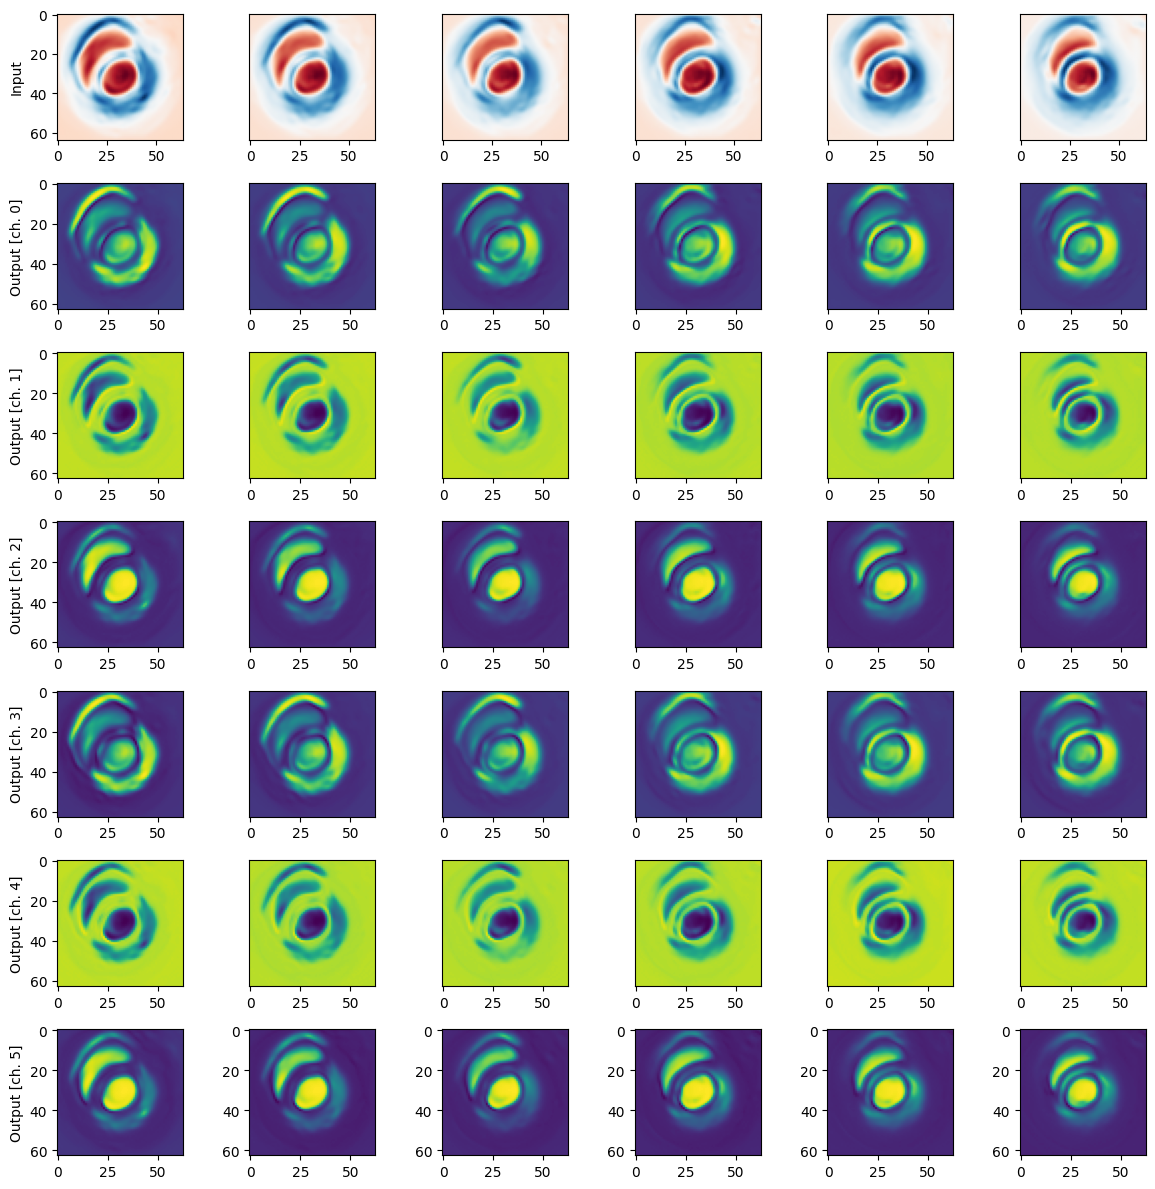

In [8]:
# PRINT SOME SAMPLES
n_samples = 6
n_channels = 6
fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(12, 12))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(train_imgs_tf_rad[k, :, :, :])

    # Plot all output channels
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_train_images_rad[k, :, : ,c])

plt.tight_layout()
plt.show()

# Modelos básicos

In [ ]:
class_names = ["C", "MCA"]

In [32]:
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30, verbose=1)
early_stopping = EarlyStopping(monitor="val_loss", patience=100, restore_best_weights=True, verbose=1)

In [33]:
# Verifica las dimensiones de las imágenes de entrenamiento
print(f'q_train_images shape: {q_train_images.shape}')
print(f'q_val_images shape: {q_val_images.shape}')
print(f'train_imgs_tf shape: {train_imgs_tf.shape}')
print(f'val_imgs_tf shape: {val_imgs_tf.shape}')

q_train_images shape: (2784, 63, 63, 24)
q_val_images shape: (800, 63, 63, 24)
train_imgs_tf shape: (2784, 64, 64, 3)
val_imgs_tf shape: (800, 64, 64, 3)


In [34]:
# Train
mask_circ = ~df_tr_circ["class"].isin(["MU","MCD"])
df_tr2_circ = df_tr_circ[mask_circ]
train_imgs_tf2_circ = train_imgs_tf_circ[mask_circ]
q_train_images2_circ = q_train_images_circ[mask_circ]

mask_rad = ~df_tr_rad["class"].isin(["MU","MCD"])
df_tr2_rad = df_tr_rad[mask_rad]
train_imgs_tf2_rad = train_imgs_tf_rad[mask_rad]
q_train_images2_rad = q_train_images_rad[mask_rad]

# Validation
mask_circ = ~df_val_circ["class"].isin(["MU","MCD"])
df_val2_circ = df_val_circ[mask_circ]
val_imgs_tf2_circ = val_imgs_tf_circ[mask_circ]
q_val_images2_circ = q_val_images_circ[mask_circ]

mask_rad = ~df_val_rad["class"].isin(["MU","MCD"])
df_val2_rad = df_val_rad[mask_rad]
val_imgs_tf2_rad = val_imgs_tf_rad[mask_rad]
q_val_images2_rad = q_val_images_rad[mask_rad]

# KFolds
mask_circ = ~df_circ["class"].isin(["MU","MCD"])
df2_circ = df_circ[mask_circ]
imgs_tf2_circ = imgs_tf_circ[mask_circ]
q_images2_circ = q_images_circ[mask_circ]

mask_rad = ~df_rad["class"].isin(["MU","MCD"])
df2_rad = df_rad[mask_rad]
imgs_tf2_rad = imgs_tf_rad[mask_rad]
q_images2_rad = q_images_rad[mask_rad]

# Test
mask_circ = ~df_test_circ["class"].isin(["MU","MCD"])
df_test2_circ = df_test_circ[mask_circ]
test_imgs_tf2_circ = test_imgs_tf_circ[mask_circ]
q_test_images2_circ = q_test_images_circ[mask_circ]

mask_rad = ~df_test_rad["class"].isin(["MU","MCD"])
df_test2_rad = df_test_rad[mask_rad]
test_imgs_tf2_rad = test_imgs_tf_rad[mask_rad]
q_test_images2_rad = q_test_images_rad[mask_rad]

In [35]:
Encoder2=OneHotEncoder(sparse=False)
train_labels2_circ=Encoder2.fit_transform(df_tr2_circ["class"].values.reshape(-1, 1))
val_labels2_circ=Encoder2.fit_transform(df_val2_circ["class"].values.reshape(-1, 1))
test_labels2_circ=Encoder2.fit_transform(df_test2_circ["class"].values.reshape(-1, 1))
labels2_circ=Encoder2.fit_transform(df2_circ["class"].values.reshape(-1, 1))

train_labels2_rad=Encoder2.fit_transform(df_tr2_rad["class"].values.reshape(-1, 1))
val_labels2_rad=Encoder2.fit_transform(df_val2_rad["class"].values.reshape(-1, 1))
test_labels2_rad=Encoder2.fit_transform(df_test2_rad["class"].values.reshape(-1, 1))
labels2_rad=Encoder2.fit_transform(df2_rad["class"].values.reshape(-1, 1))

Encoder2.categories_

c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was rename

[array(['C', 'MCA'], dtype=object)]

In [36]:
k=5
kf = KFold(n_splits=k, shuffle=True, random_state=random_seed)

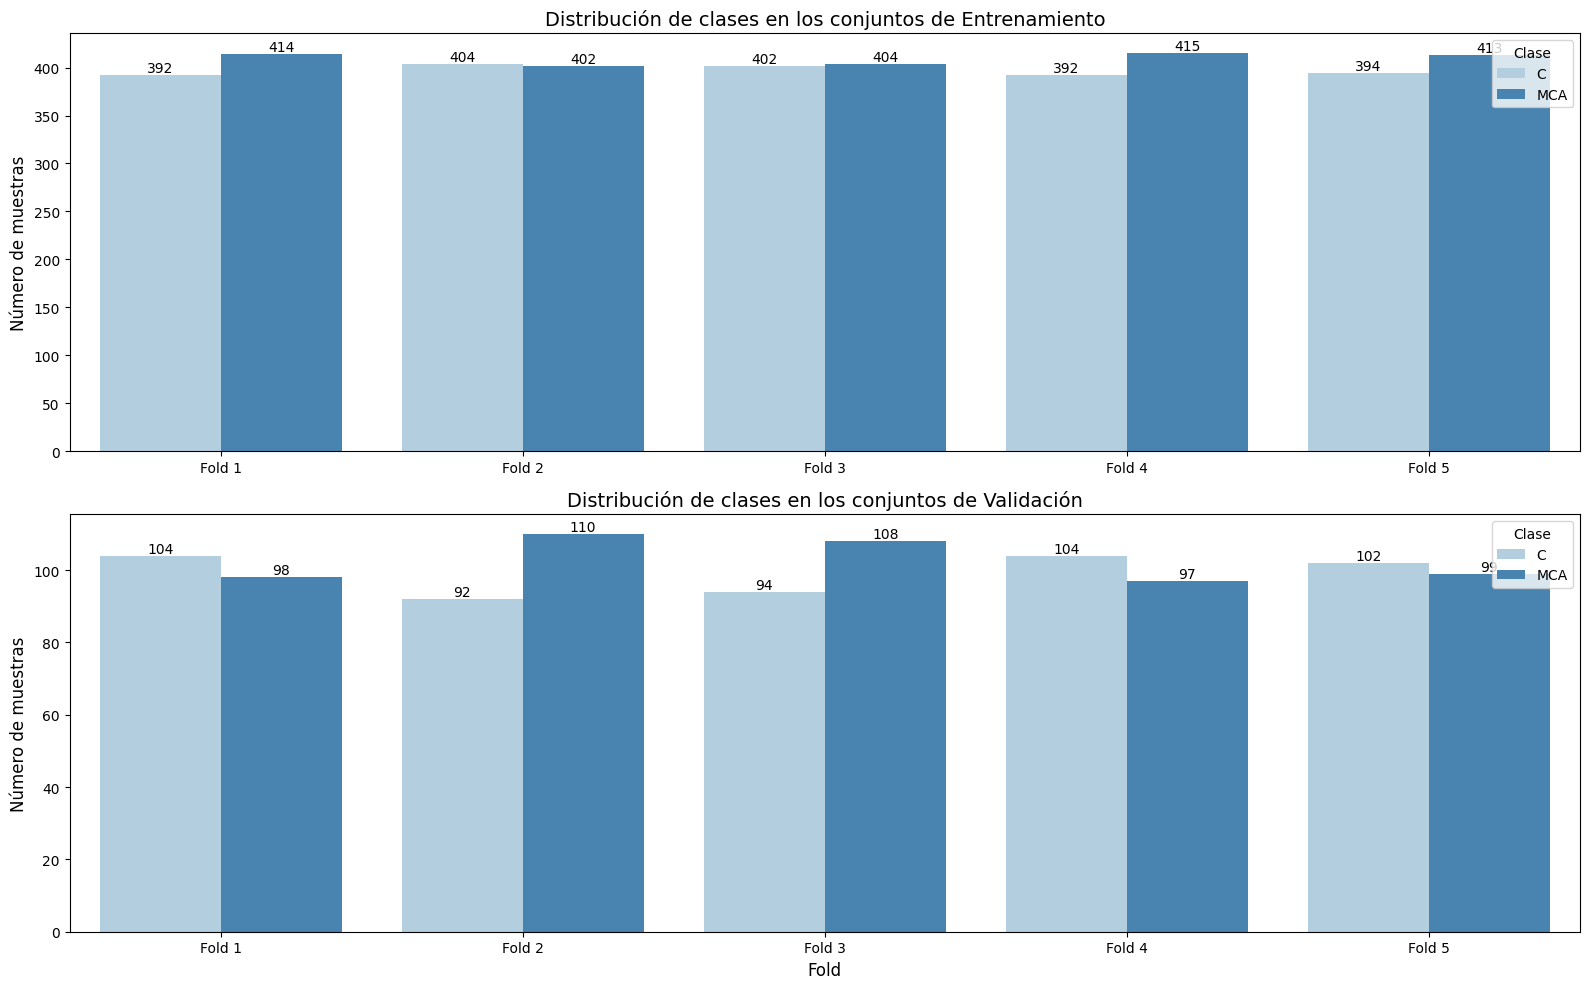

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import KFold
import seaborn as sns

class_names = ["C", "MCA"]

# Inicializar KFold
kf = KFold(n_splits=k, shuffle=True, random_state=random_seed)

train_c_counts = []
train_mca_counts = []
val_c_counts = []
val_mca_counts = []
fold_numbers = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(df2_rad)):
    y_train_fold = df2_rad["class"].values[train_idx]
    y_val_fold = df2_rad["class"].values[val_idx]

    train_counts = pd.Series(y_train_fold).value_counts()
    train_c_counts.append(train_counts.get("C", 0))
    train_mca_counts.append(train_counts.get("MCA", 0))

    val_counts = pd.Series(y_val_fold).value_counts()
    val_c_counts.append(val_counts.get("C", 0))
    val_mca_counts.append(val_counts.get("MCA", 0))
    
    fold_numbers.append(f"Fold {fold_idx+1}")

df_train = pd.DataFrame({
    'Fold': fold_numbers,
    'C': train_c_counts,
    'MCA': train_mca_counts
})

df_val = pd.DataFrame({
    'Fold': fold_numbers,
    'C': val_c_counts,
    'MCA': val_mca_counts
})

df_train_long = pd.melt(df_train, id_vars=['Fold'], value_vars=['C', 'MCA'], 
                        var_name='Clase', value_name='Conteo')
df_val_long = pd.melt(df_val, id_vars=['Fold'], value_vars=['C', 'MCA'], 
                      var_name='Clase', value_name='Conteo')

plt.figure(figsize=(16, 10))

plt.subplot(2, 1, 1)
sns.barplot(x='Fold', y='Conteo', hue='Clase', data=df_train_long, palette='Blues')
plt.title('Distribución de clases en los conjuntos de Entrenamiento', fontsize=14)
plt.ylabel('Número de muestras', fontsize=12)
plt.xlabel('')
plt.legend(title='Clase')

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'bottom', fontsize=10)

plt.subplot(2, 1, 2)
sns.barplot(x='Fold', y='Conteo', hue='Clase', data=df_val_long, palette='Blues')
plt.title('Distribución de clases en los conjuntos de Validación', fontsize=14)
plt.ylabel('Número de muestras', fontsize=12)
plt.xlabel('Fold', fontsize=12)
plt.legend(title='Clase')

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Datos Radial

## QCNN

### KFold

In [ ]:
kf.get_n_splits(q_images2_rad,labels2_rad)
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(q_images2_rad,labels2_rad)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = q_images2_rad[train_idx], q_images2_rad[val_idx]
    train_labels, val_labels = labels2_rad[train_idx], labels2_rad[val_idx]
    
    # Instanciar el modelo
    model = qcnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=2, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/qcnn_fold{fold+1}.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=512,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/qcnn_fold{fold+1}.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500


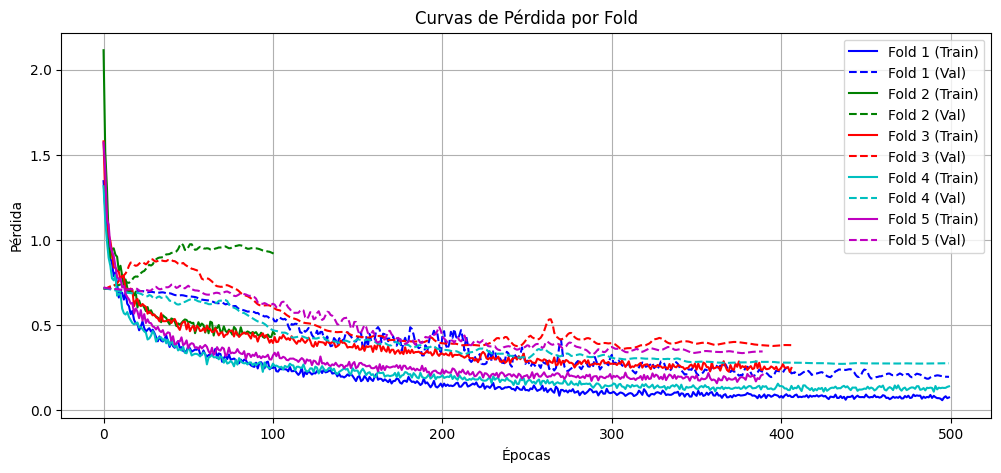

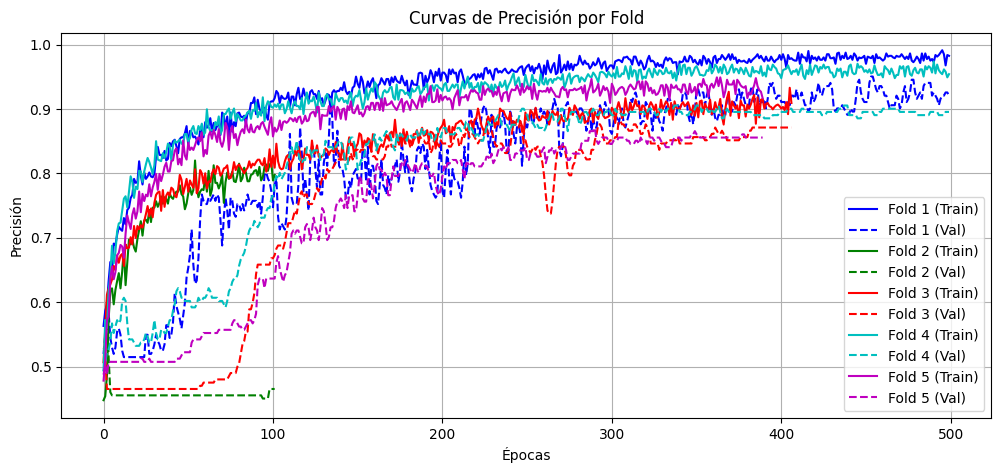

In [ ]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

In [26]:
model_paths = [f"checkpoints/qcnn_fold{i+1}.h5" for i in range(5)]
history_paths = [f"history/qcnn_fold{i+1}.pkl" for i in range(5)]

models = [load_model(path) for path in model_paths]
histories = [pickle.load(open(path, "rb")) for path in history_paths]

In [ ]:
fold_results = []

for fold_idx, (model, history) in enumerate(zip(models, histories)):
    print(f"Evaluando fold {fold_idx+1}...")
    
    # Predicciones
    preds = model.predict(q_test_images2_rad)
    
    # AUC por clase
    auc_scores = []
    fpr = dict()
    tpr = dict()
    thresholds = dict()

    for i in range(test_labels2_rad.shape[1]):
        auc = roc_auc_score(test_labels2_rad[:, i], preds[:, i])
        auc_scores.append(auc)
        fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels2_rad[:, i], preds[:, i])

    mean_auc = np.mean(auc_scores)
    
    # F1 y ACC
    f1 = f1_score(test_labels2_rad, np.round(preds), average='micro')
    acc = accuracy_score(test_labels2_rad, np.round(preds))
    
    # Guardar resultados
    fold_results.append({
        "predictions": preds,
        "history": history,
        "auc_scores": auc_scores,
        "fpr": fpr,
        "tpr": tpr,
        "mean_auc": mean_auc,
        "f1": f1,
        "acc": acc
    })

Evaluando fold 1...
4/4 [==============================] - 0s 22ms/step
Evaluando fold 2...
4/4 [==============================] - 0s 3ms/step
Evaluando fold 3...
4/4 [==============================] - 0s 3ms/step
Evaluando fold 4...
4/4 [==============================] - 0s 3ms/step
Evaluando fold 5...
4/4 [==============================] - 0s 3ms/step


Graficando resultados del fold 1...


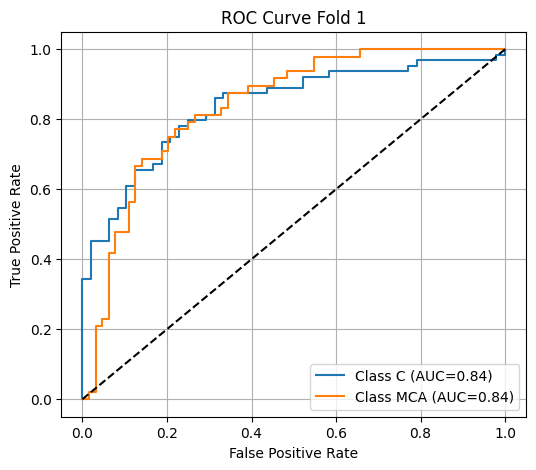

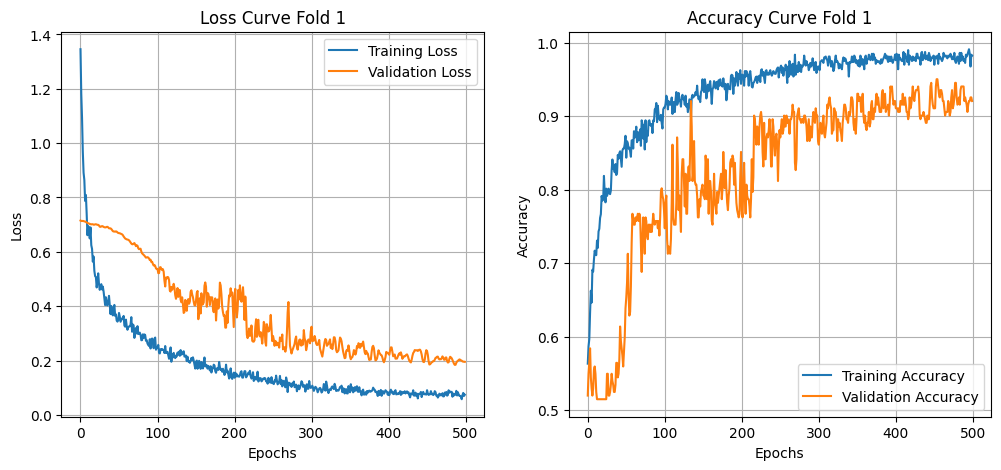

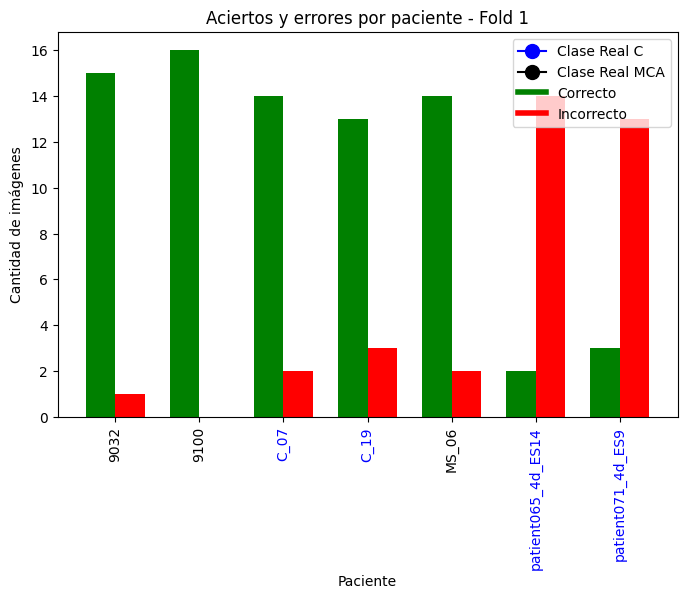

Graficando resultados del fold 2...


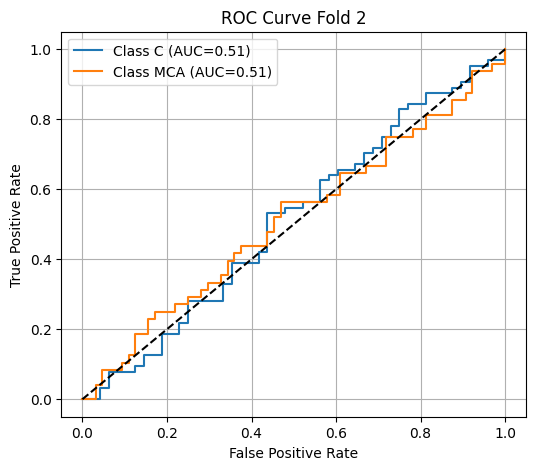

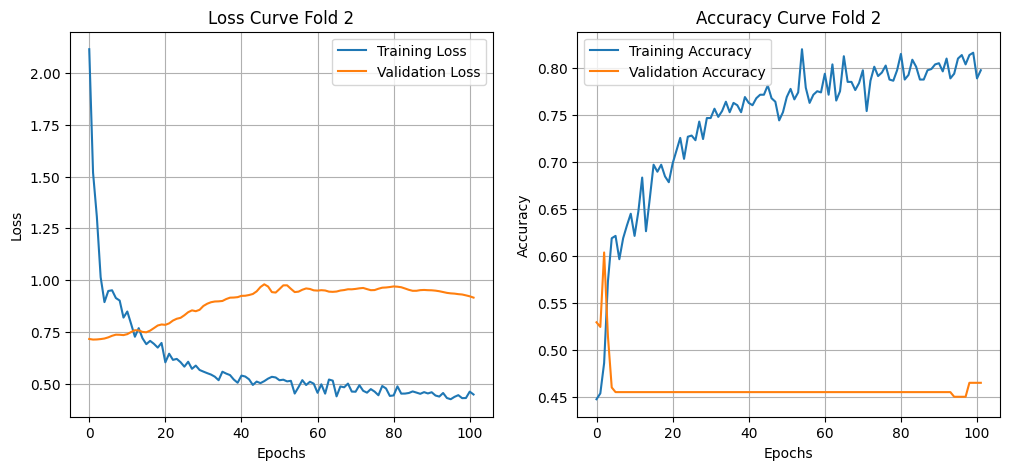

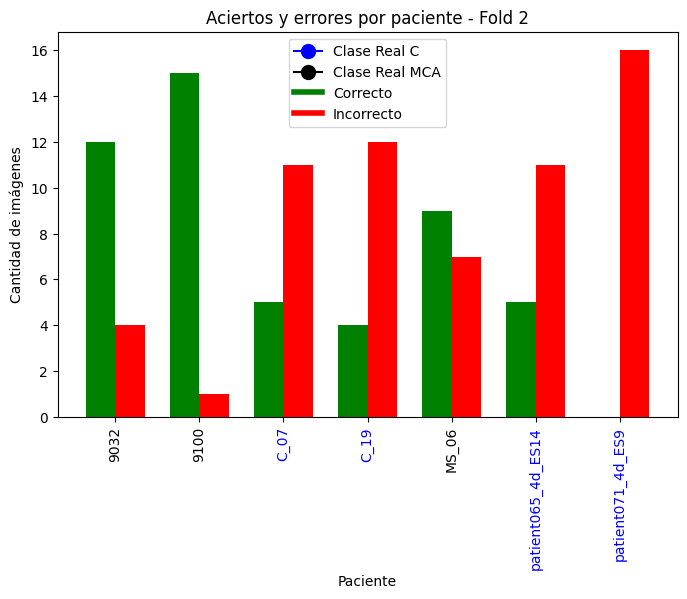

Graficando resultados del fold 3...


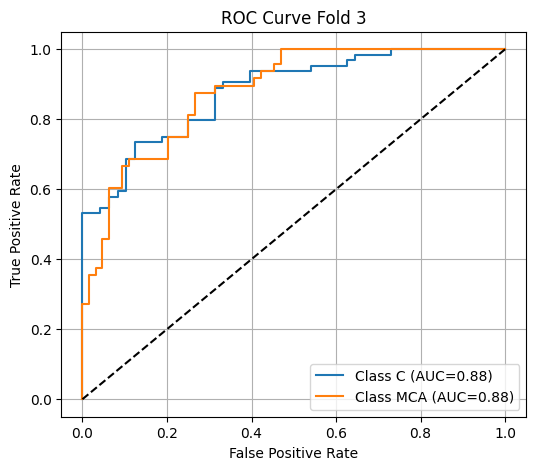

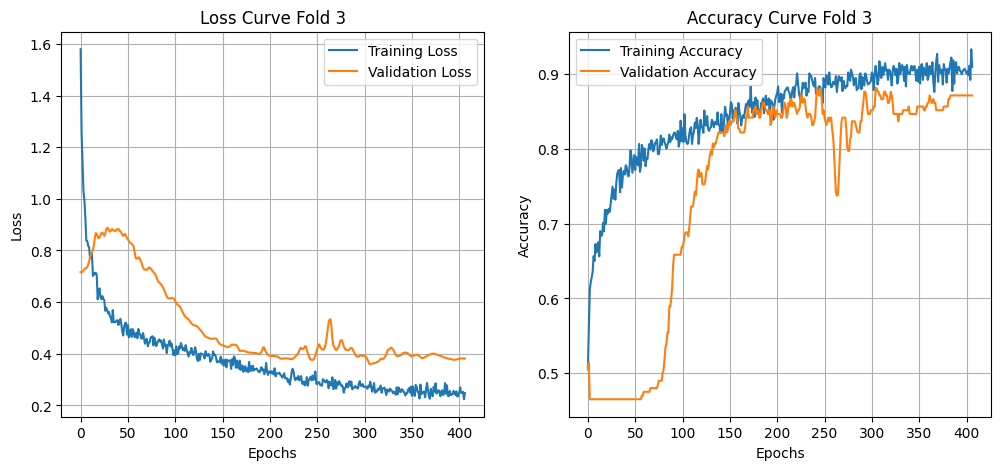

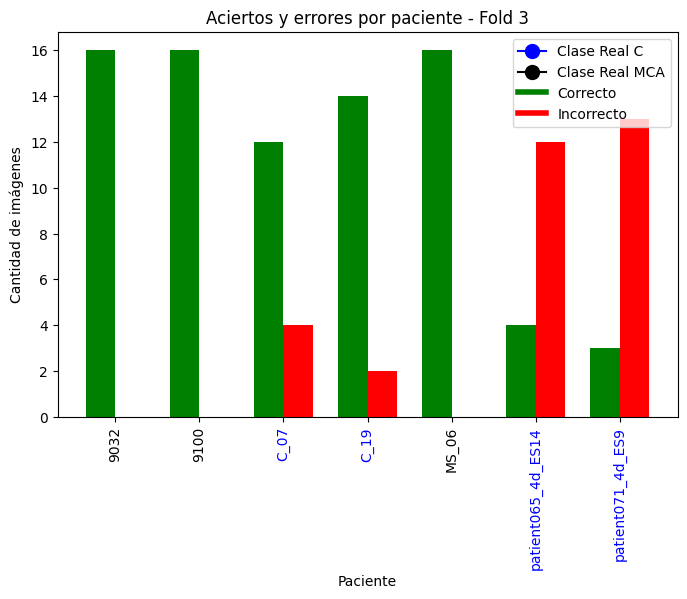

Graficando resultados del fold 4...


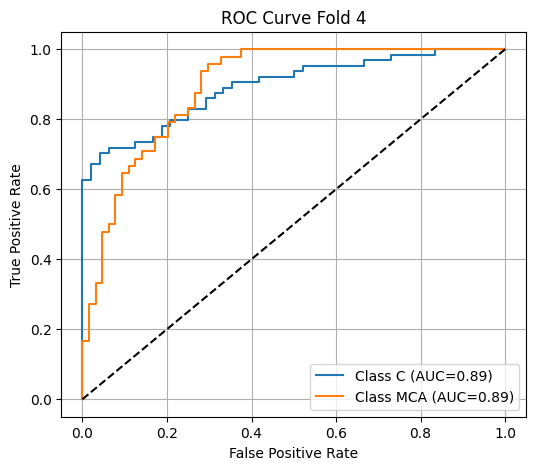

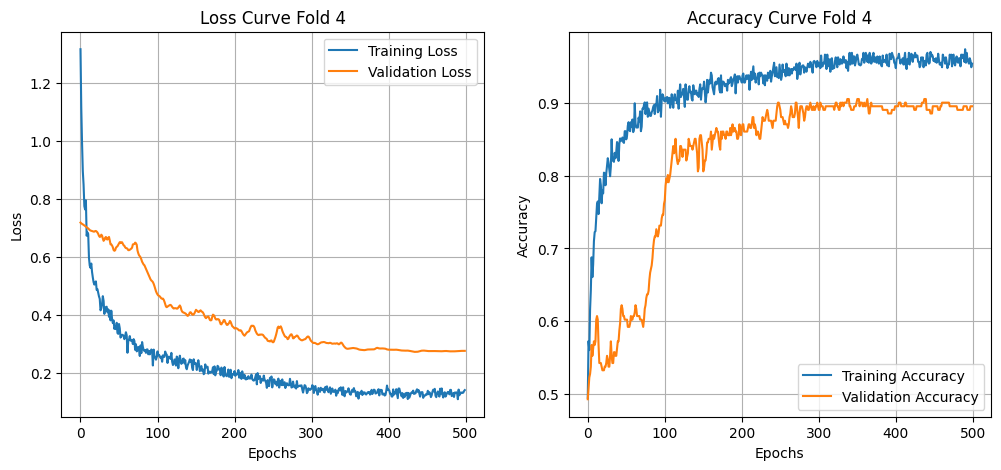

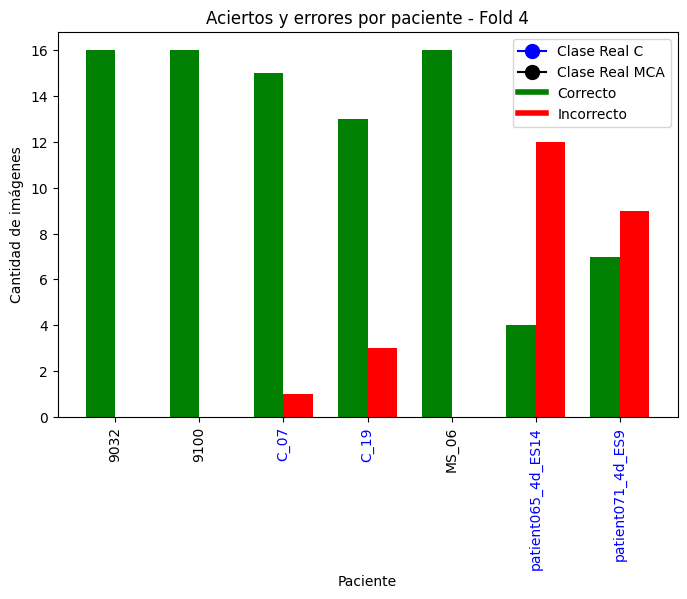

Graficando resultados del fold 5...


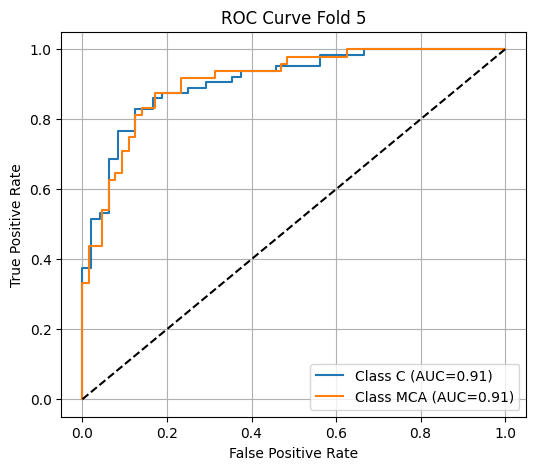

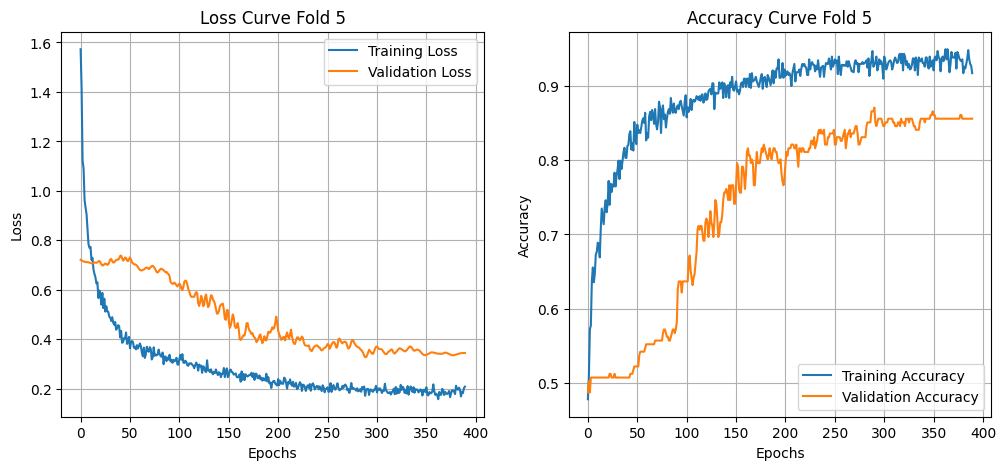

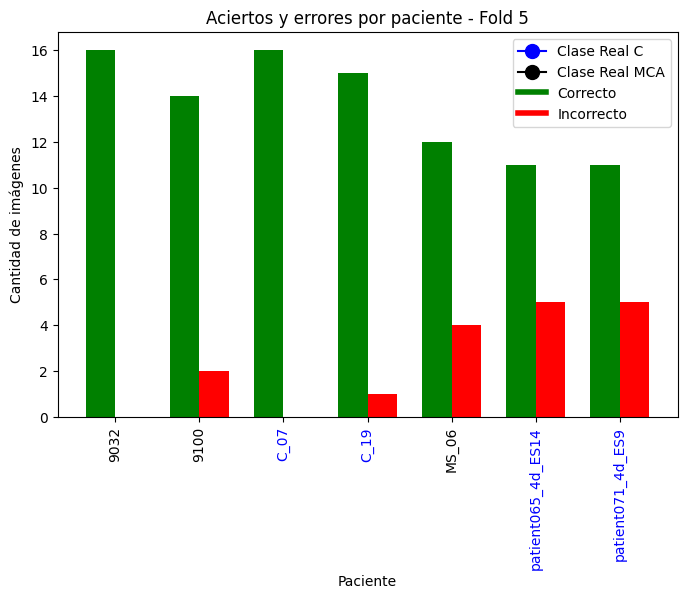

In [ ]:
for fold_idx, result in enumerate(fold_results):
    print(f"Graficando resultados del fold {fold_idx+1}...")

    preds = result["predictions"]
    history = result["history"]
    auc_scores = result["auc_scores"]
    fpr = result["fpr"]
    tpr = result["tpr"]

    ## 1. Curva ROC
    plt.figure(figsize=(6, 5))
    for i in range(test_labels2_rad.shape[1]):
        plt.plot(fpr[i], tpr[i], label=f'Class {Encoder2.categories_[0][i]} (AUC={auc_scores[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve Fold {fold_idx+1}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    ## 2. Loss & Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Loss Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()
    plt.show()

    ## 3. Correctos/Incorrectos por paciente
    df = df_test2_rad.copy()
    df["pred"] = [Encoder2.categories_[0][i] for i in preds.argmax(axis=1)]
    df["correct"] = df["pred"] == df["class"]
    df_grouped = df.groupby("patient_name")["correct"].value_counts().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    bar_width = 0.35
    x = np.arange(len(df_grouped))

    ax.bar(x - bar_width/2, df_grouped[True], width=bar_width, label="Correcto", color="green")
    ax.bar(x + bar_width/2, df_grouped[False], width=bar_width, label="Incorrecto", color="red")

    colores = ["blue" if df[df["patient_name"] == p]["class"].iloc[0] == "C" else "black" for p in df_grouped.index]
    ax.set_xticks(x)
    ax.set_xticklabels(df_grouped.index)
    for tick, color in zip(ax.get_xticklabels(), colores):
        tick.set_color(color)
    plt.xticks(rotation=90)

    ax.set_xlabel("Paciente")
    ax.set_ylabel("Cantidad de imágenes")
    ax.set_title(f"Aciertos y errores por paciente - Fold {fold_idx+1}")
    handle_azul = mlines.Line2D([], [], marker='o', color='blue', label='Clase Real C', markersize=10)
    handle_negro = mlines.Line2D([], [], marker='o', color='black', label='Clase Real MCA', markersize=10)
    handle_correcto = mlines.Line2D([], [], color='green', lw=4, label='Correcto')
    handle_incorrecto = mlines.Line2D([], [], color='red', lw=4, label='Incorrecto')
    ax.legend(handles=[handle_azul, handle_negro, handle_correcto, handle_incorrecto])

    plt.show()


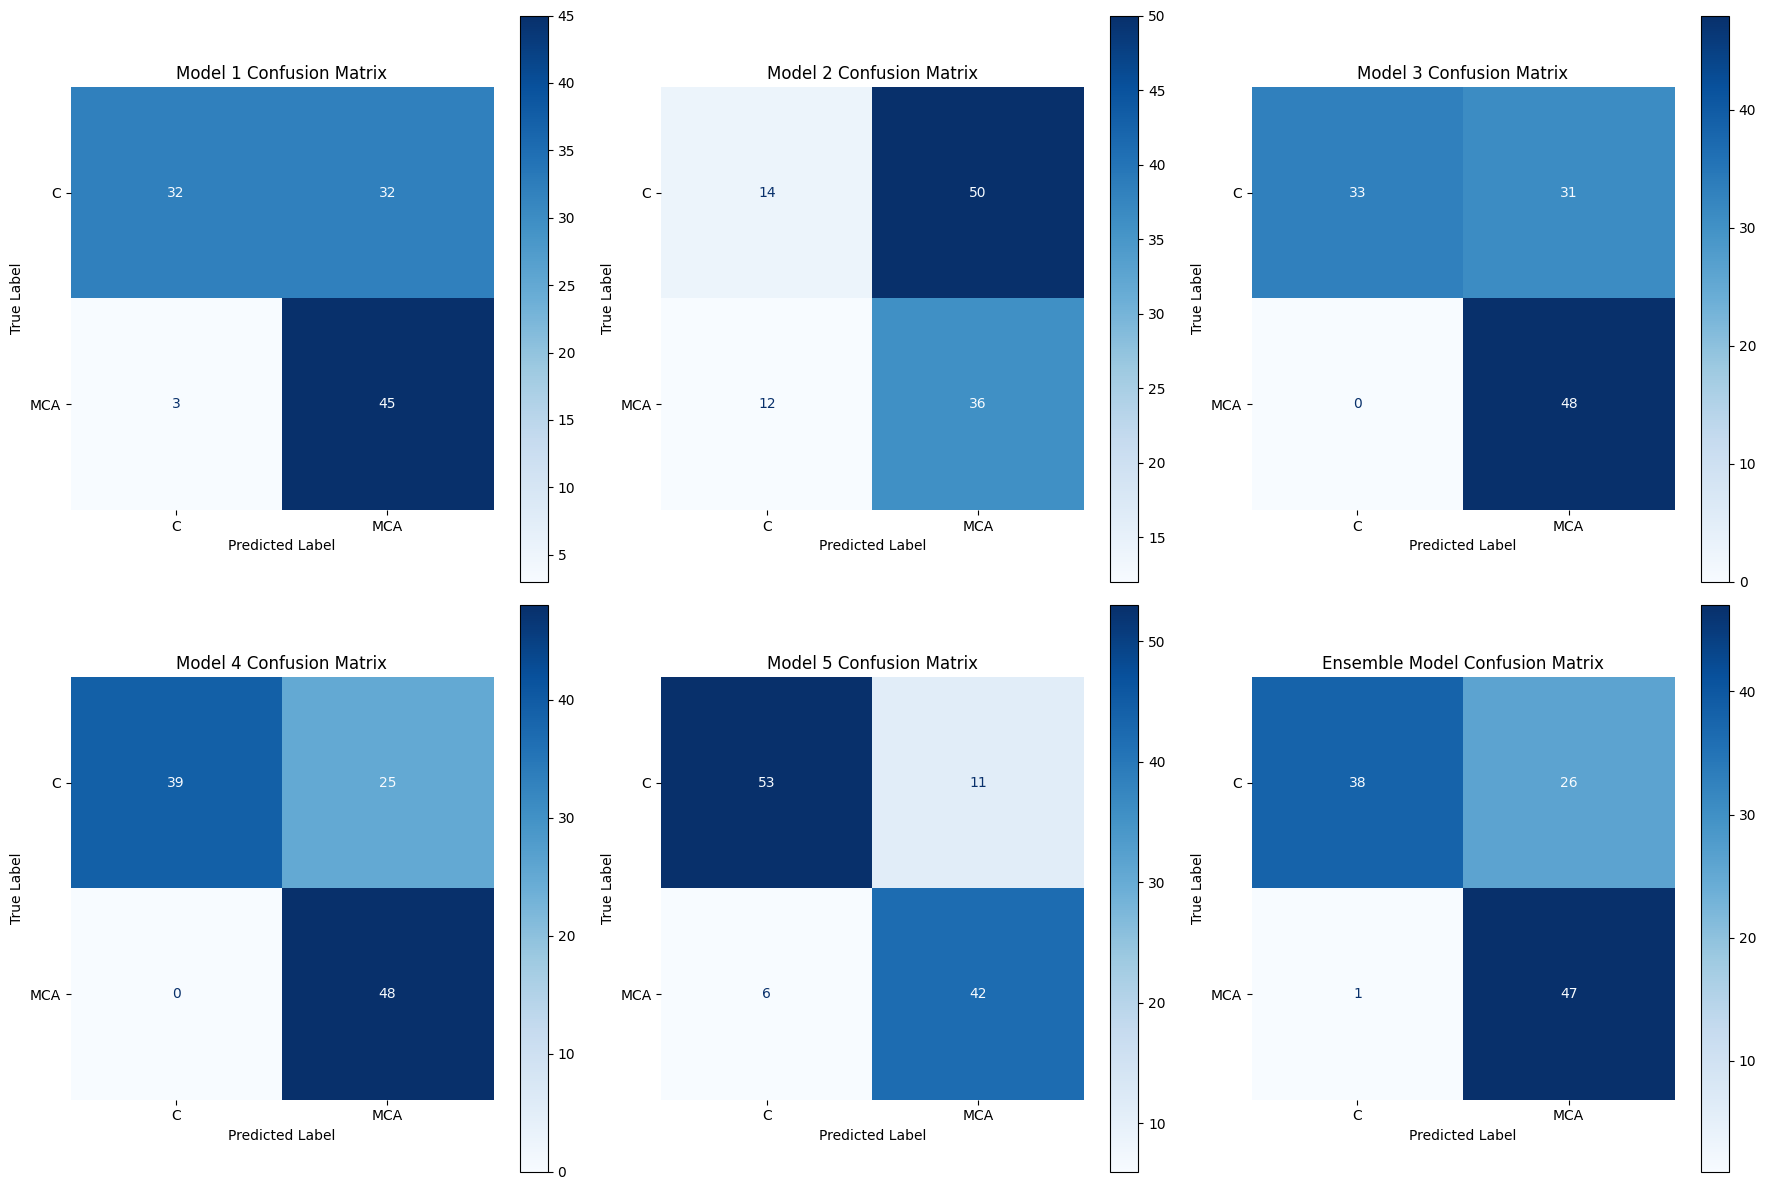

In [ ]:
# Plot confusion matrices
plot_confusion_matrices(models, q_test_images2_rad, test_labels2_rad, class_names)

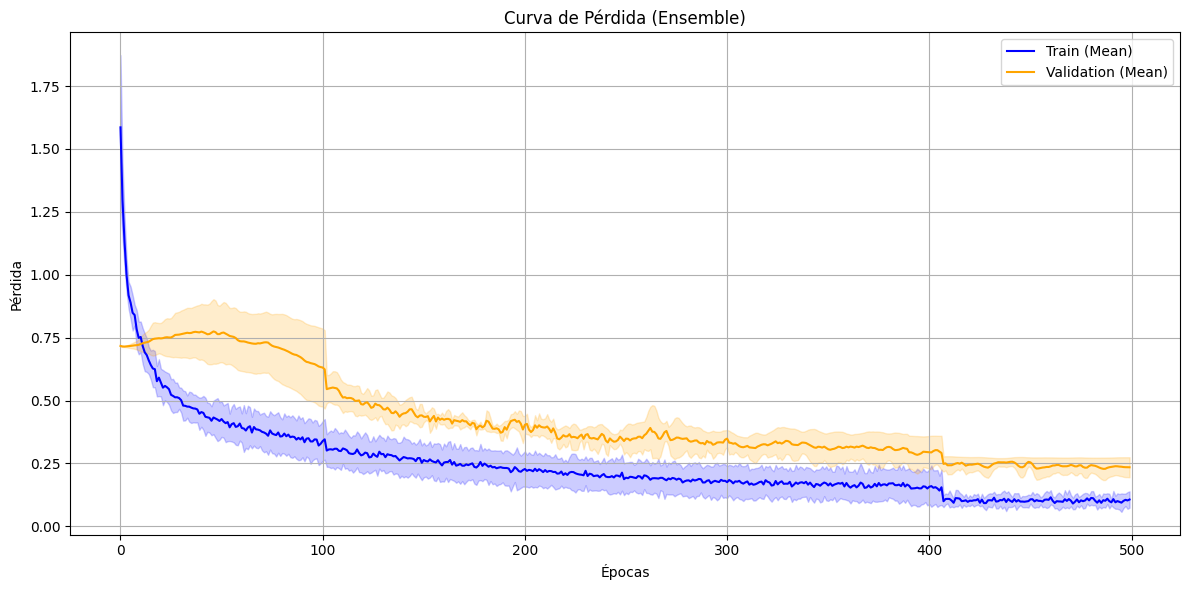

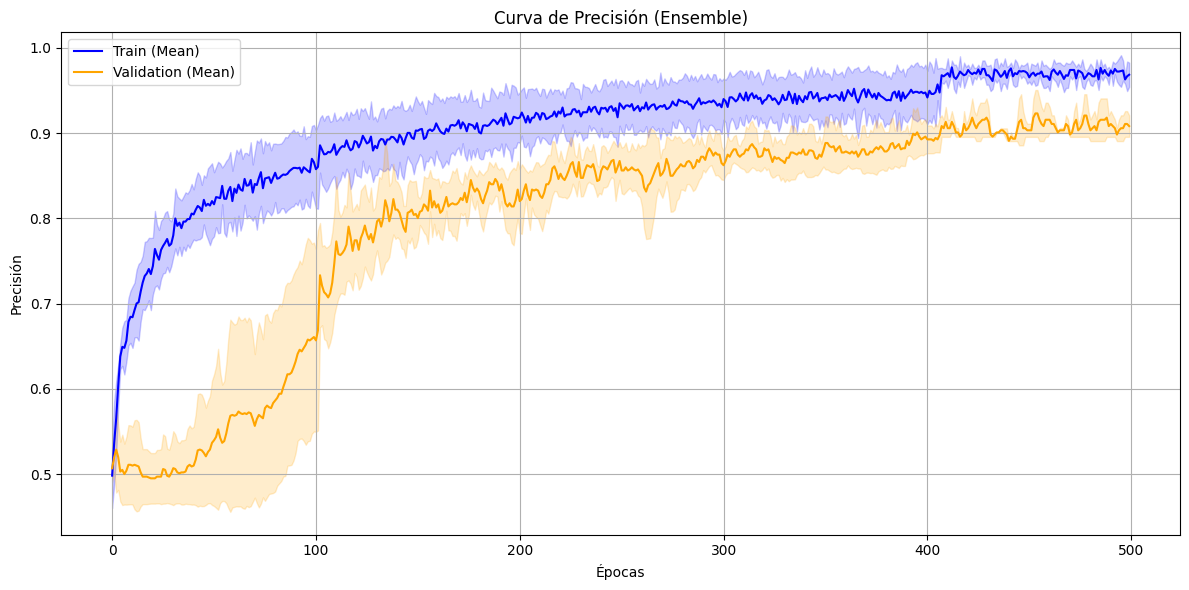

In [ ]:
plot_ensemble_curve(histories)

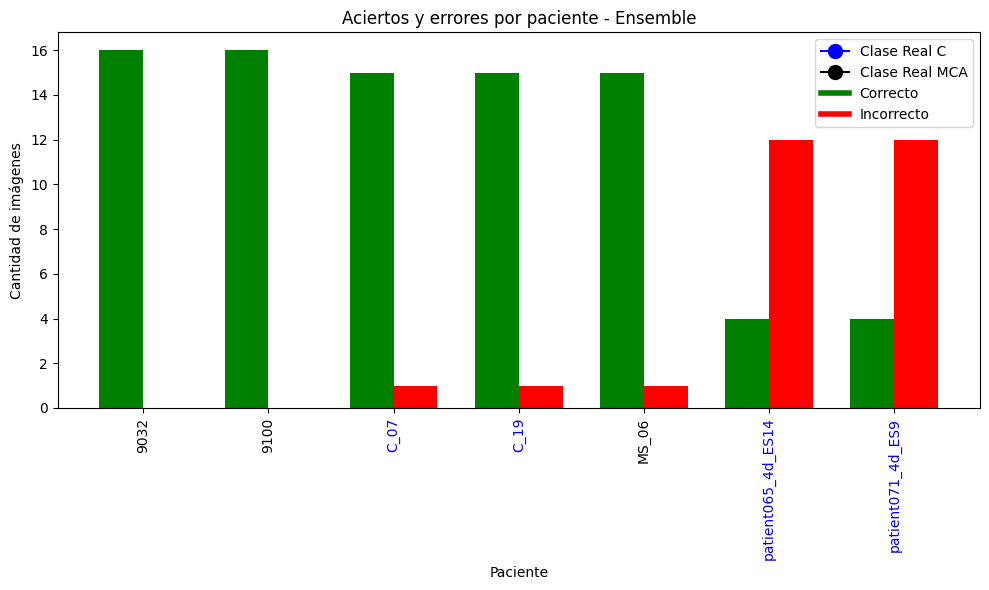

In [38]:
plot_ensemble_patients(models, histories, q_test_images2_rad, df_test2_rad, Encoder2)

## CNN

### KFold

In [107]:
kf.get_n_splits(imgs_tf2_rad,labels2_rad)
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(imgs_tf2_rad,labels2_rad)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = imgs_tf2_rad[train_idx], imgs_tf2_rad[val_idx]
    train_labels, val_labels = labels2_rad[train_idx], labels2_rad[val_idx]
    
    # Instanciar el modelo
    model = cnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=2, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/cnn_fold{fold+1}.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=512,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/cnn_fold{fold+1}.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500

Epoch 1: val_loss improved from inf to 0.71630, saving model to checkpoints\cnn_fold1.h5
2/2 - 1s - loss: 1.2780 - accuracy: 0.5347 - val_loss: 0.7163 - val_accuracy: 0.5050 - lr: 0.0010 - 888ms/epoch - 444ms/step
Epoch 2/500

Epoch 2: val_loss did not improve from 0.71630
2/2 - 0s - loss: 1.2652 - accuracy: 0.5596 - val_loss: 0.7164 - val_accuracy: 0.4901 - lr: 0.0010 - 100ms/epoch - 50ms/step
Epoch 3/500

Epoch 3: val_loss improved from 0.71630 to 0.71486, saving model to checkpoints\cnn_fold1.h5
2/2 - 0s - loss: 1.1319 - accuracy: 0.5633 - val_loss: 0.7149 - val_accuracy: 0.5099 - lr: 0.0010 - 143ms/epoch - 71ms/step
Epoch 4/500

Epoch 4: val_loss improved from 0.71486 to 0.71351, saving model to checkpoints\cnn_fold1.h5
2/2 - 0s - loss: 1.0671 - accuracy: 0.6241 - val_loss: 0.7135 - val_accuracy: 0.5149 - lr: 0.0010 - 136ms/epoch - 68ms/step
Epoch 5/500

Epoch 5: val_loss improved from 0.71351 to 0.71230, saving model to checkpoints\cnn_fold1.h5


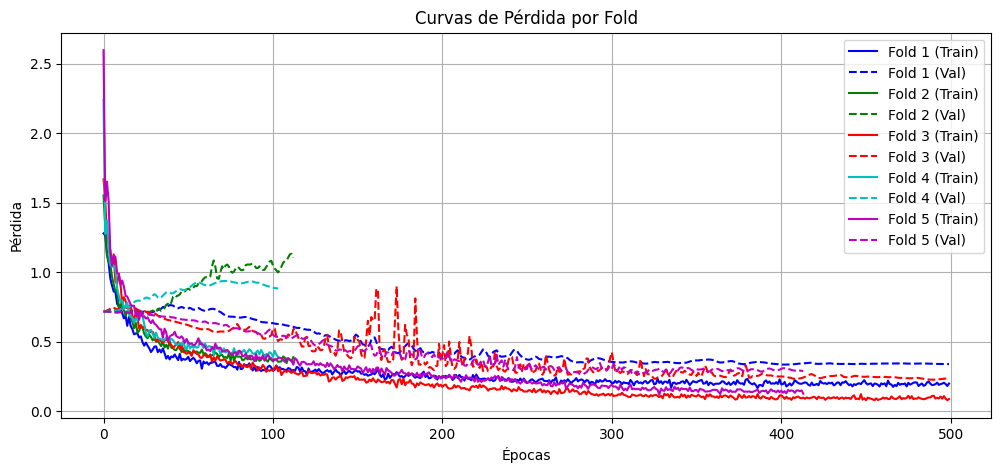

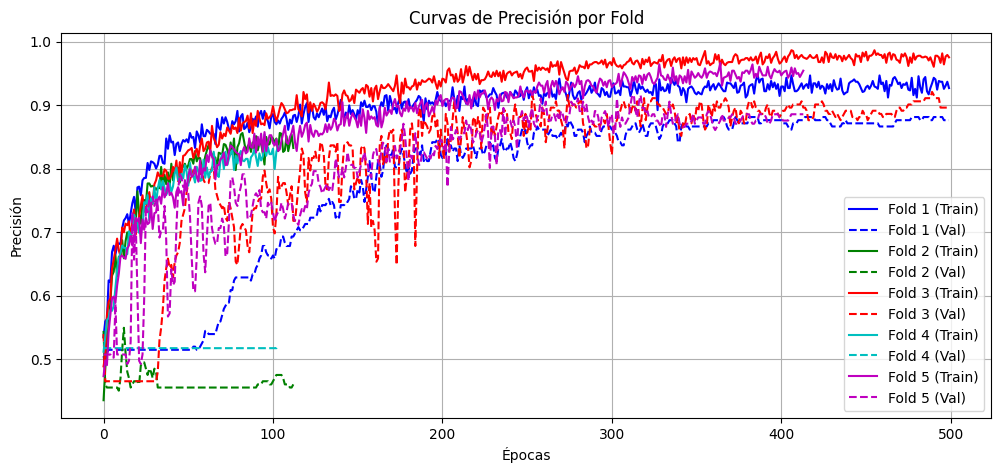

In [108]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

In [39]:
model_paths = [f"checkpoints/cnn_fold{i+1}.h5" for i in range(5)]
history_paths = [f"history/cnn_fold{i+1}.pkl" for i in range(5)]

models = [load_model(path) for path in model_paths]
histories = [pickle.load(open(path, "rb")) for path in history_paths]

In [110]:
fold_results = []

for fold_idx, (model, history) in enumerate(zip(models, histories)):
    print(f"Evaluando fold {fold_idx+1}...")
    
    # Predicciones
    preds = model.predict(test_imgs_tf2_rad)
    
    # AUC por clase
    auc_scores = []
    fpr = dict()
    tpr = dict()
    thresholds = dict()

    for i in range(test_labels2_rad.shape[1]):
        auc = roc_auc_score(test_labels2_rad[:, i], preds[:, i])
        auc_scores.append(auc)
        fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels2_rad[:, i], preds[:, i])

    mean_auc = np.mean(auc_scores)
    
    # F1 y ACC
    f1 = f1_score(test_labels2_rad, np.round(preds), average='micro')
    acc = accuracy_score(test_labels2_rad, np.round(preds))
    
    # Guardar resultados
    fold_results.append({
        "predictions": preds,
        "history": history,
        "auc_scores": auc_scores,
        "fpr": fpr,
        "tpr": tpr,
        "mean_auc": mean_auc,
        "f1": f1,
        "acc": acc
    })

Evaluando fold 1...
4/4 [==============================] - 0s 2ms/step
Evaluando fold 2...
4/4 [==============================] - 0s 2ms/step
Evaluando fold 3...
4/4 [==============================] - 0s 2ms/step
Evaluando fold 4...
4/4 [==============================] - 0s 2ms/step
Evaluando fold 5...
4/4 [==============================] - 0s 2ms/step


Graficando resultados del fold 1...


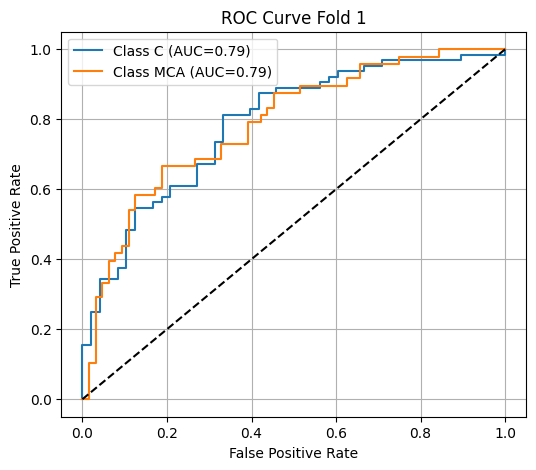

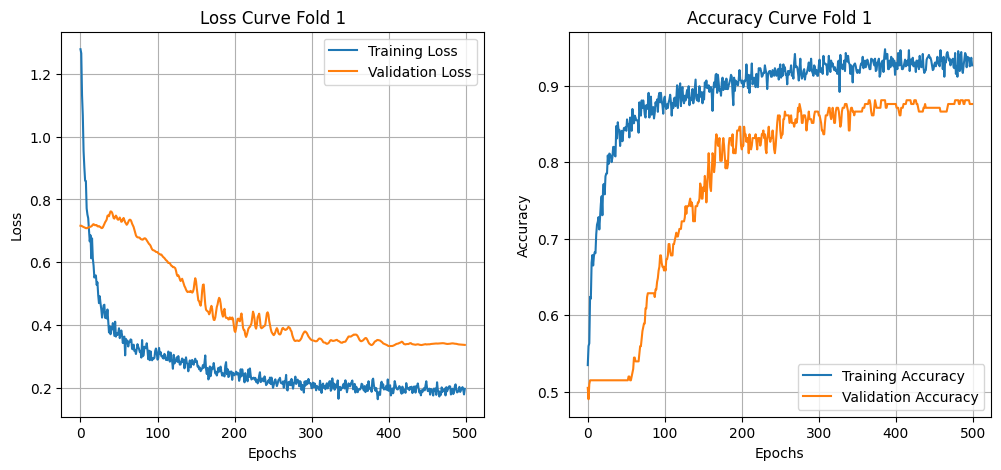

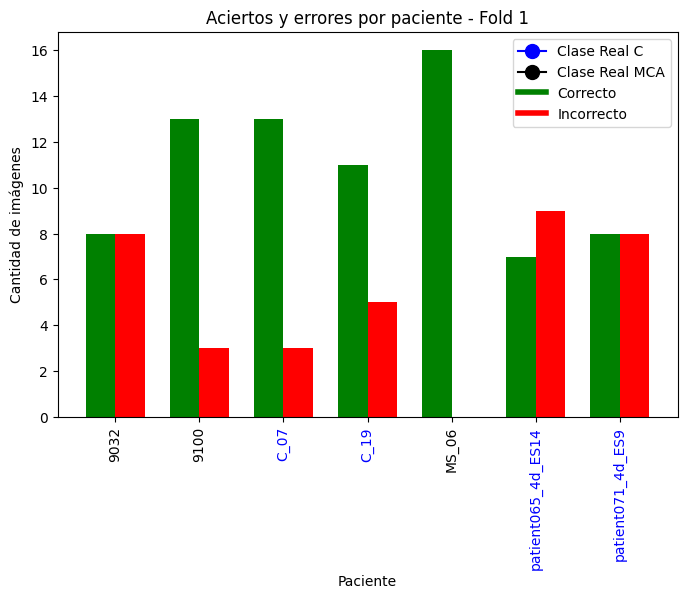

Graficando resultados del fold 2...


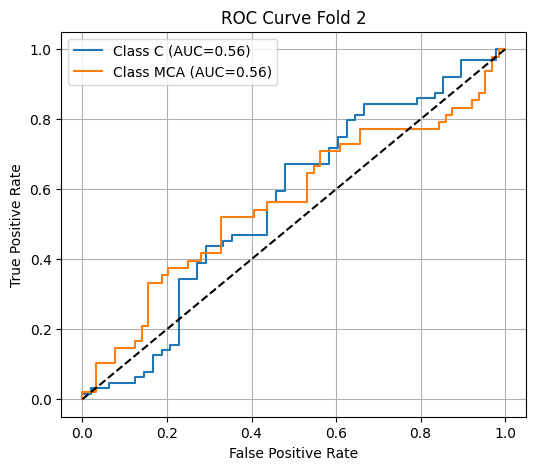

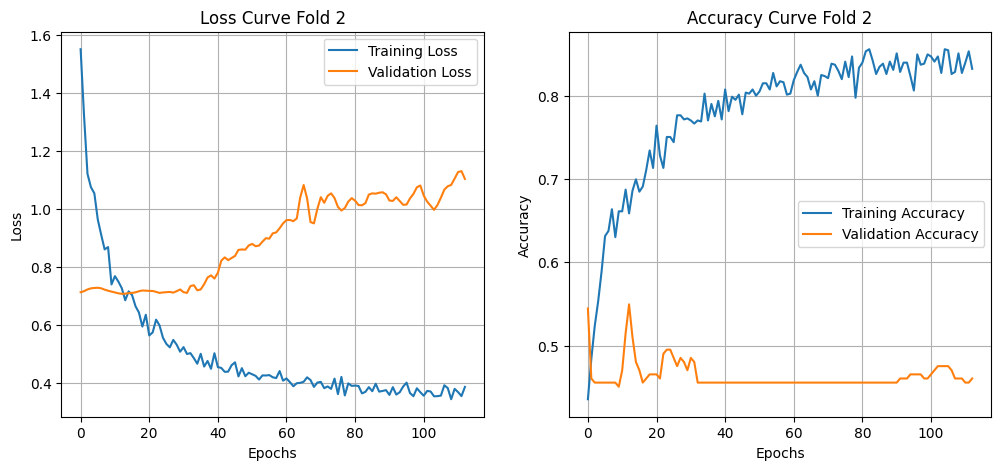

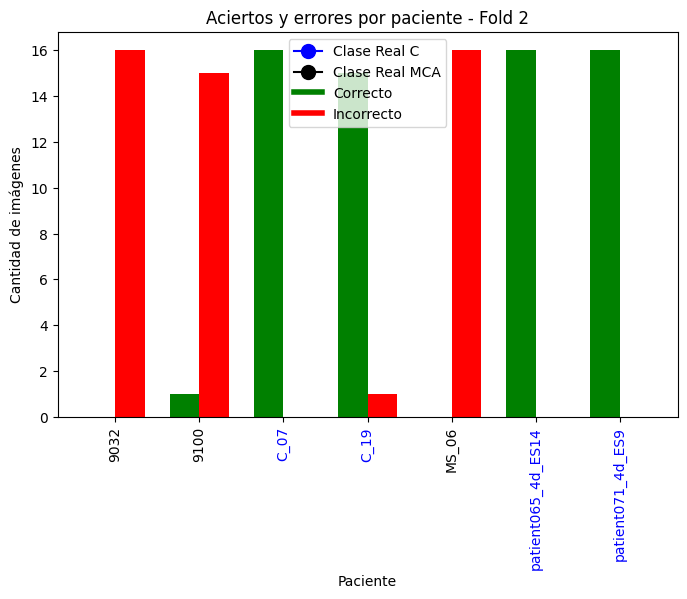

Graficando resultados del fold 3...


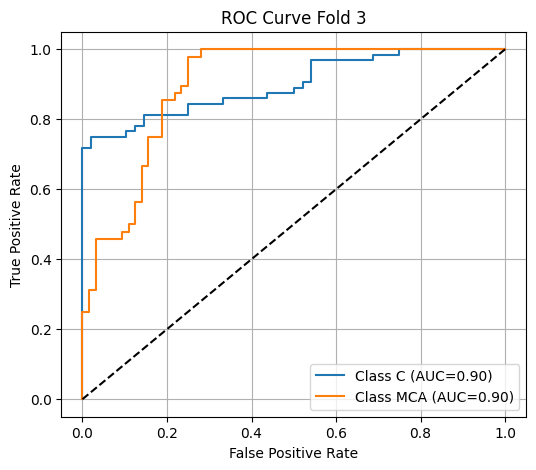

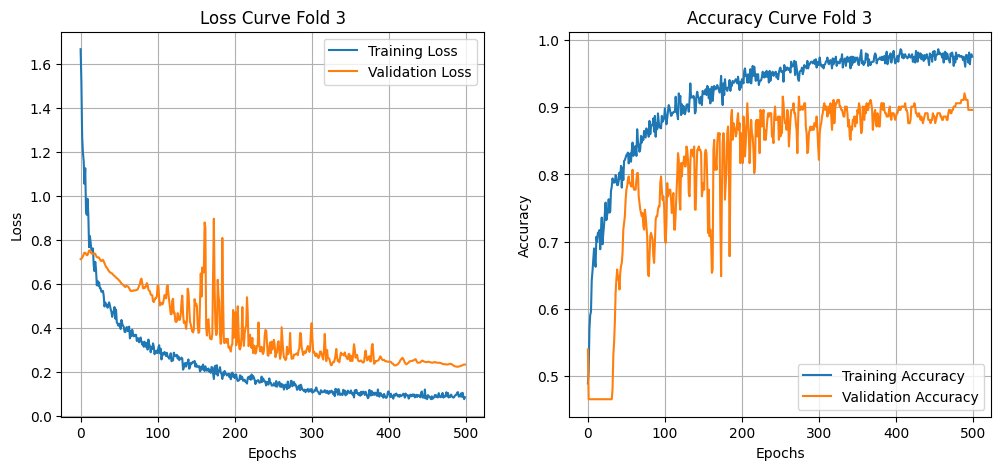

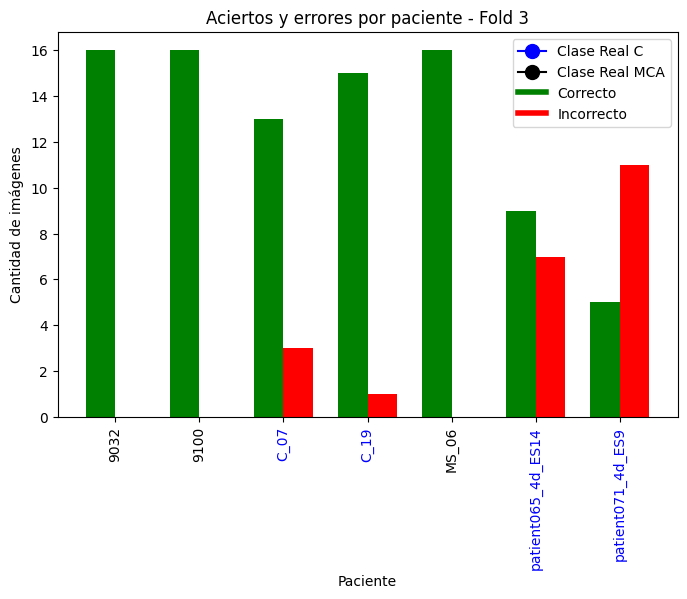

Graficando resultados del fold 4...


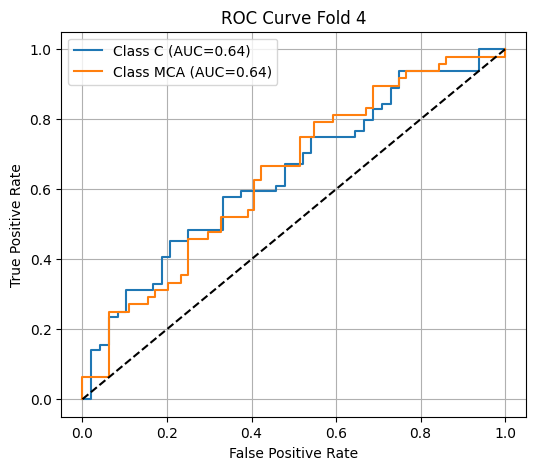

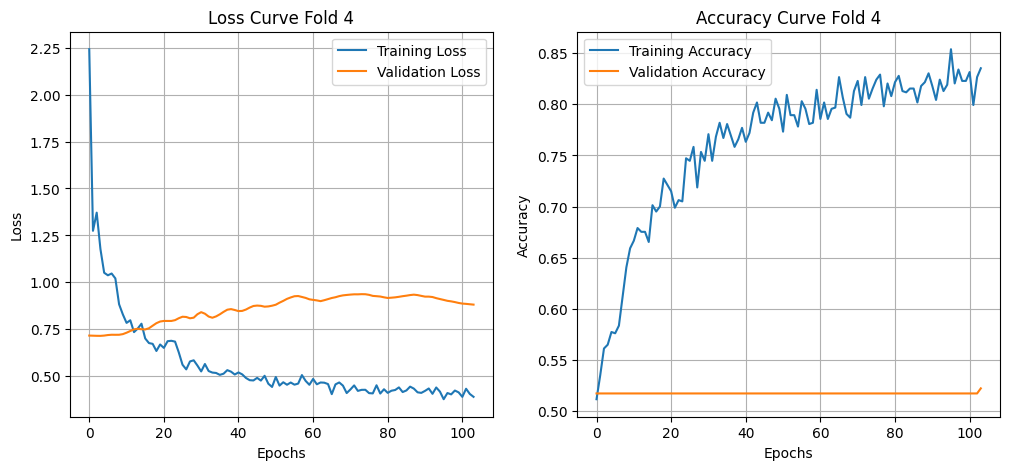

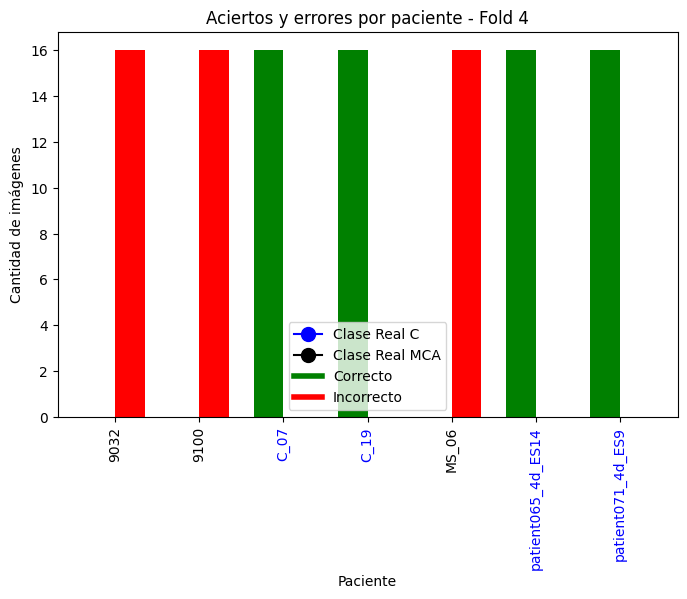

Graficando resultados del fold 5...


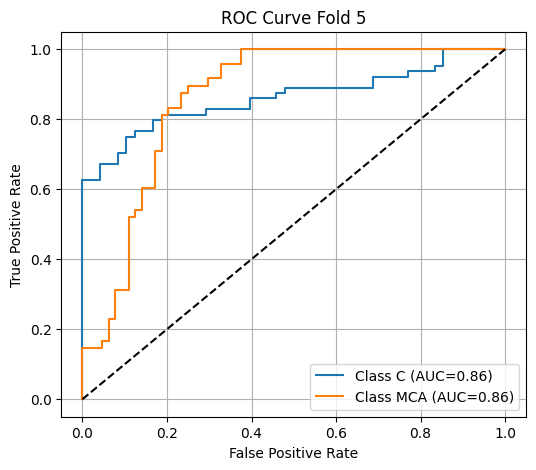

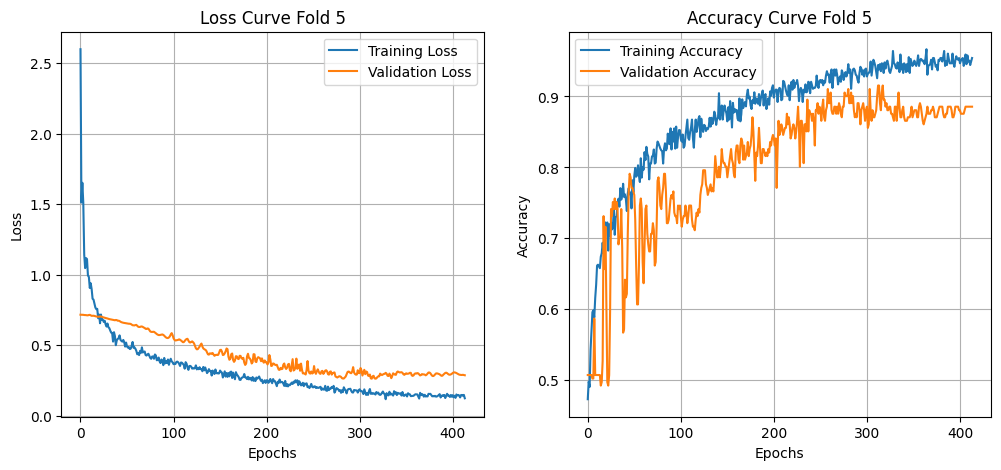

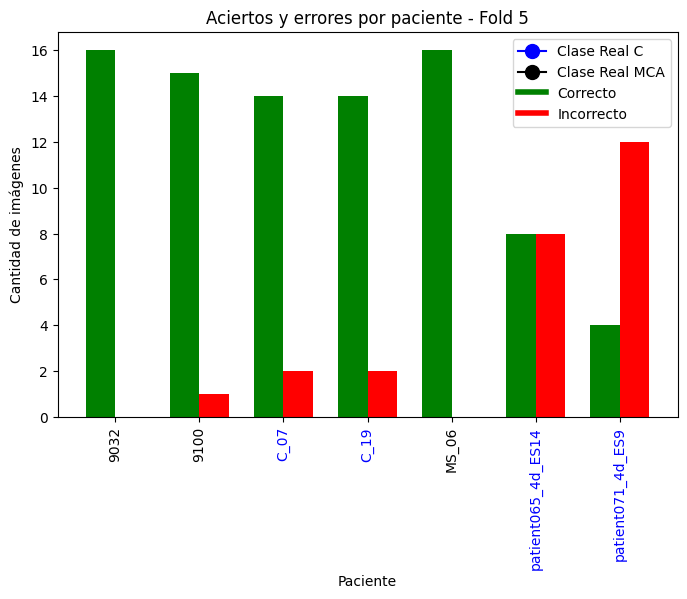

In [111]:
for fold_idx, result in enumerate(fold_results):
    print(f"Graficando resultados del fold {fold_idx+1}...")

    preds = result["predictions"]
    history = result["history"]
    auc_scores = result["auc_scores"]
    fpr = result["fpr"]
    tpr = result["tpr"]

    ## 1. Curva ROC
    plt.figure(figsize=(6, 5))
    for i in range(test_labels2_rad.shape[1]):
        plt.plot(fpr[i], tpr[i], label=f'Class {Encoder2.categories_[0][i]} (AUC={auc_scores[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve Fold {fold_idx+1}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    ## 2. Loss & Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Loss Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()
    plt.show()

    ## 3. Correctos/Incorrectos por paciente
    df = df_test2_rad.copy()
    df["pred"] = [Encoder2.categories_[0][i] for i in preds.argmax(axis=1)]
    df["correct"] = df["pred"] == df["class"]
    df_grouped = df.groupby("patient_name")["correct"].value_counts().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    bar_width = 0.35
    x = np.arange(len(df_grouped))

    ax.bar(x - bar_width/2, df_grouped[True], width=bar_width, label="Correcto", color="green")
    ax.bar(x + bar_width/2, df_grouped[False], width=bar_width, label="Incorrecto", color="red")

    colores = ["blue" if df[df["patient_name"] == p]["class"].iloc[0] == "C" else "black" for p in df_grouped.index]
    ax.set_xticks(x)
    ax.set_xticklabels(df_grouped.index)
    for tick, color in zip(ax.get_xticklabels(), colores):
        tick.set_color(color)
    plt.xticks(rotation=90)

    ax.set_xlabel("Paciente")
    ax.set_ylabel("Cantidad de imágenes")
    ax.set_title(f"Aciertos y errores por paciente - Fold {fold_idx+1}")
    handle_azul = mlines.Line2D([], [], marker='o', color='blue', label='Clase Real C', markersize=10)
    handle_negro = mlines.Line2D([], [], marker='o', color='black', label='Clase Real MCA', markersize=10)
    handle_correcto = mlines.Line2D([], [], color='green', lw=4, label='Correcto')
    handle_incorrecto = mlines.Line2D([], [], color='red', lw=4, label='Incorrecto')
    ax.legend(handles=[handle_azul, handle_negro, handle_correcto, handle_incorrecto])

    plt.show()


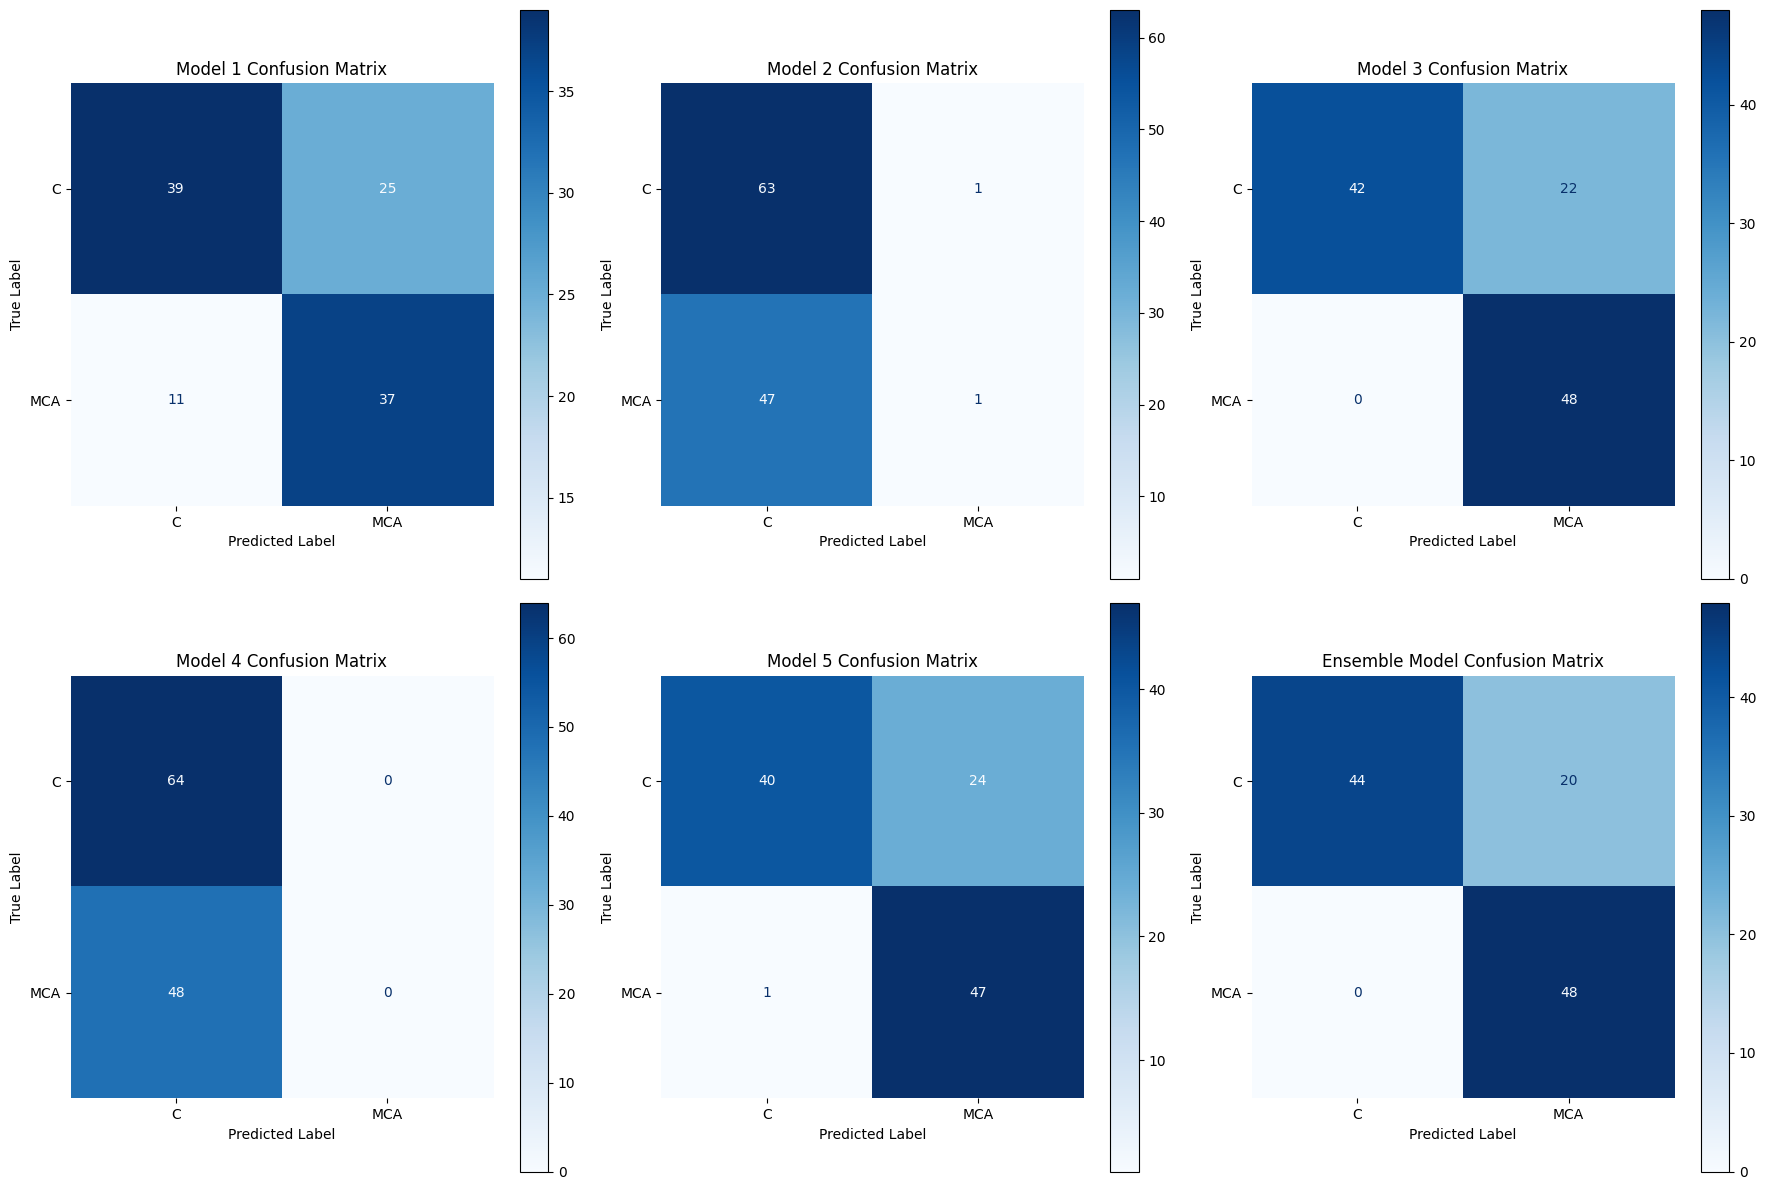

In [112]:
plot_confusion_matrices(models, test_imgs_tf2_rad, test_labels2_rad, class_names)

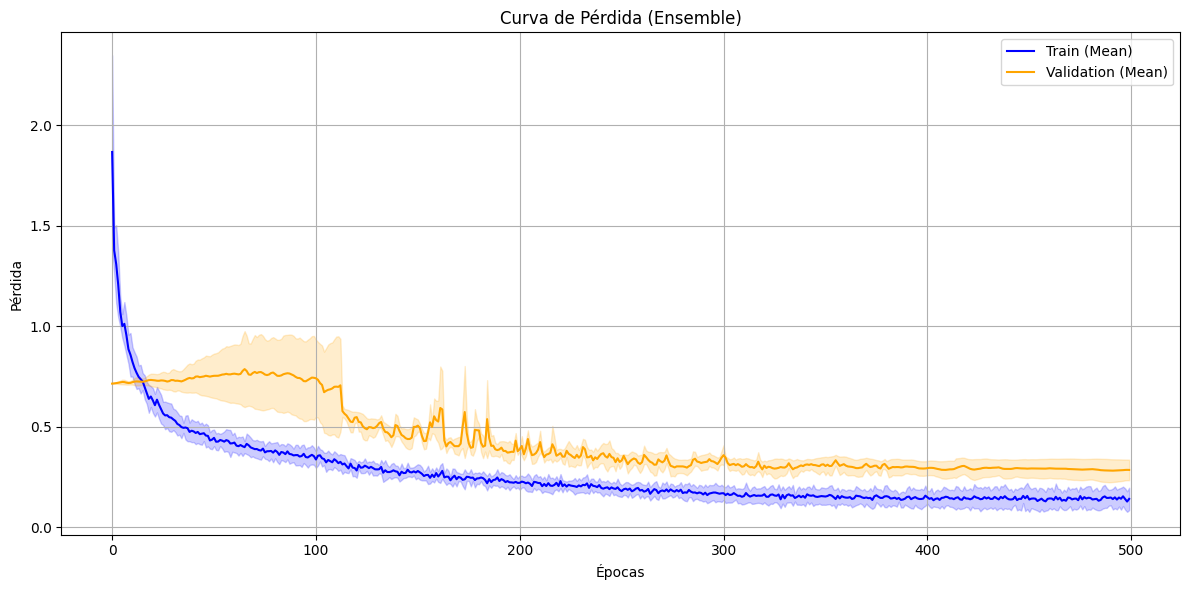

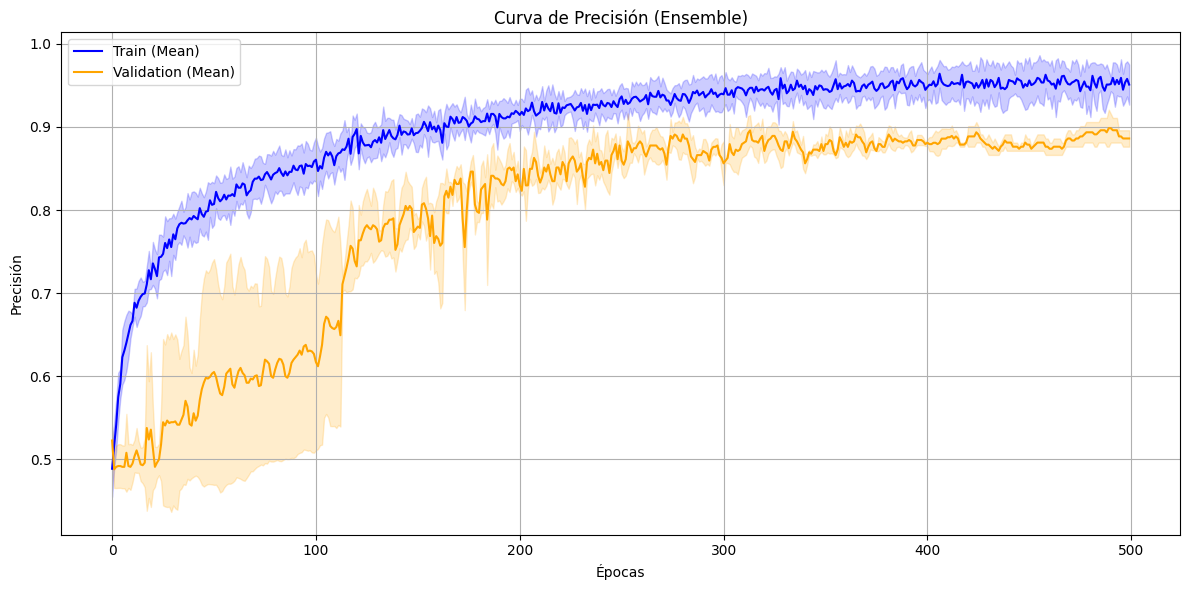

In [ ]:
plot_ensemble_curve(histories)

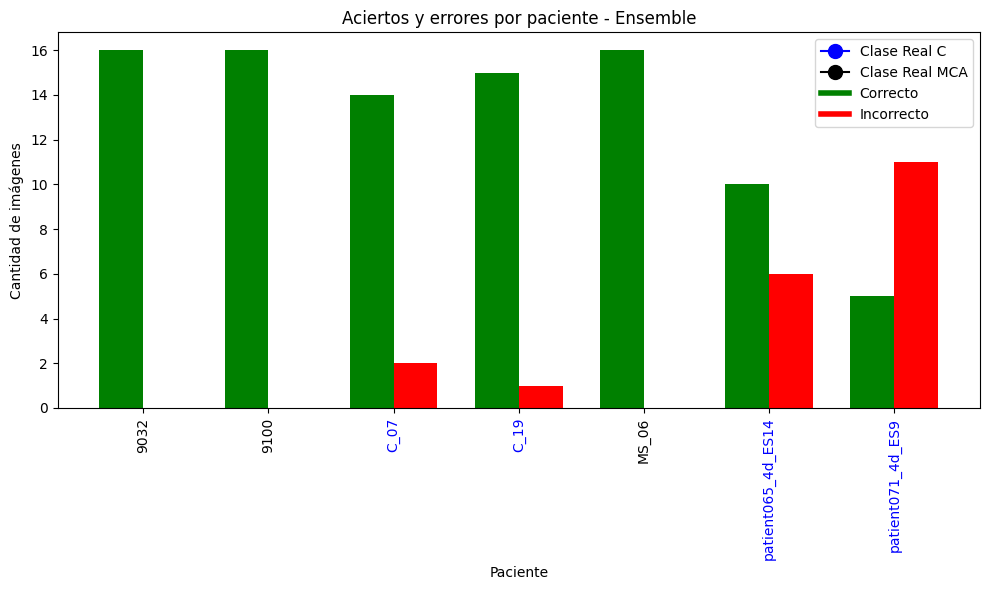

In [41]:
plot_ensemble_patients(models, histories, test_imgs_tf2_rad, df_test2_rad, Encoder2)

# Datos Circunferencial

## QCNN

### KFold

In [137]:
kf.get_n_splits(q_images2_circ,labels2_circ)
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(q_images2_circ,labels2_circ)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = q_images2_circ[train_idx], q_images2_circ[val_idx]
    train_labels, val_labels = labels2_circ[train_idx], labels2_circ[val_idx]
    
    # Instanciar el modelo
    model = qcnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=2, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/qcnn_fold{fold+1}_circ.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=512,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/qcnn_fold{fold+1}_circ.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500

Epoch 1: val_loss improved from inf to 0.71675, saving model to checkpoints\qcnn_fold1_circ.h5
2/2 - 1s - loss: 1.4704 - accuracy: 0.5310 - val_loss: 0.7168 - val_accuracy: 0.4851 - lr: 0.0010 - 911ms/epoch - 455ms/step
Epoch 2/500

Epoch 2: val_loss improved from 0.71675 to 0.71548, saving model to checkpoints\qcnn_fold1_circ.h5
2/2 - 0s - loss: 1.4583 - accuracy: 0.5099 - val_loss: 0.7155 - val_accuracy: 0.4901 - lr: 0.0010 - 151ms/epoch - 76ms/step
Epoch 3/500

Epoch 3: val_loss improved from 0.71548 to 0.71379, saving model to checkpoints\qcnn_fold1_circ.h5
2/2 - 0s - loss: 1.2945 - accuracy: 0.5261 - val_loss: 0.7138 - val_accuracy: 0.4752 - lr: 0.0010 - 157ms/epoch - 79ms/step
Epoch 4/500

Epoch 4: val_loss improved from 0.71379 to 0.71211, saving model to checkpoints\qcnn_fold1_circ.h5
2/2 - 0s - loss: 1.2386 - accuracy: 0.5546 - val_loss: 0.7121 - val_accuracy: 0.5743 - lr: 0.0010 - 161ms/epoch - 80ms/step
Epoch 5/500

Epoch 5: val_loss impro

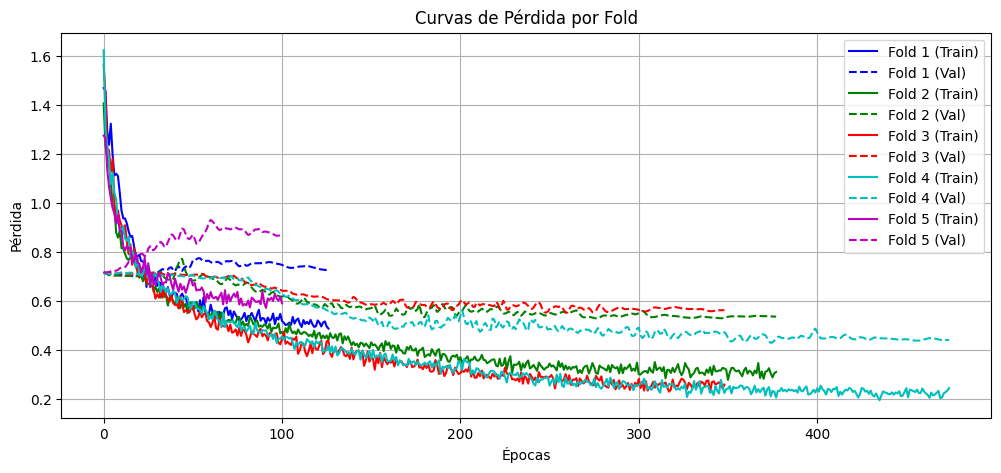

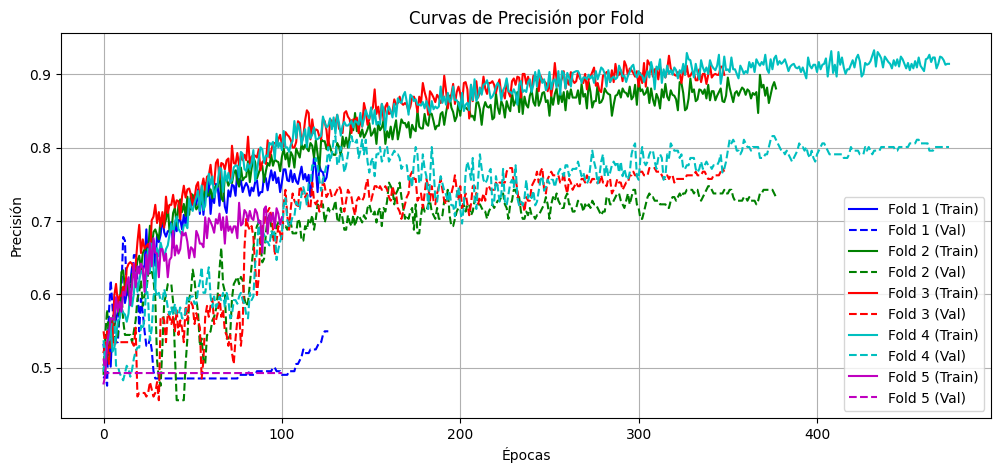

In [138]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

In [42]:
model_paths = [f"checkpoints/qcnn_fold{i+1}_circ.h5" for i in range(5)]
history_paths = [f"history/qcnn_fold{i+1}_circ.pkl" for i in range(5)]

models = [load_model(path) for path in model_paths]
histories = [pickle.load(open(path, "rb")) for path in history_paths]

In [140]:
fold_results = []

for fold_idx, (model, history) in enumerate(zip(models, histories)):
    print(f"Evaluando fold {fold_idx+1}...")
    
    # Predicciones
    preds = model.predict(q_test_images2_circ)
    
    # AUC por clase
    auc_scores = []
    fpr = dict()
    tpr = dict()
    thresholds = dict()

    for i in range(test_labels2_circ.shape[1]):
        auc = roc_auc_score(test_labels2_circ[:, i], preds[:, i])
        auc_scores.append(auc)
        fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels2_circ[:, i], preds[:, i])

    mean_auc = np.mean(auc_scores)
    
    # F1 y ACC
    f1 = f1_score(test_labels2_circ, np.round(preds), average='micro')
    acc = accuracy_score(test_labels2_circ, np.round(preds))
    
    # Guardar resultados
    fold_results.append({
        "predictions": preds,
        "history": history,
        "auc_scores": auc_scores,
        "fpr": fpr,
        "tpr": tpr,
        "mean_auc": mean_auc,
        "f1": f1,
        "acc": acc
    })

Evaluando fold 1...
4/4 [==============================] - 0s 3ms/step
Evaluando fold 2...
4/4 [==============================] - 0s 3ms/step
Evaluando fold 3...
4/4 [==============================] - 0s 3ms/step
Evaluando fold 4...
4/4 [==============================] - 0s 3ms/step
Evaluando fold 5...
4/4 [==============================] - 0s 3ms/step


Graficando resultados del fold 1...


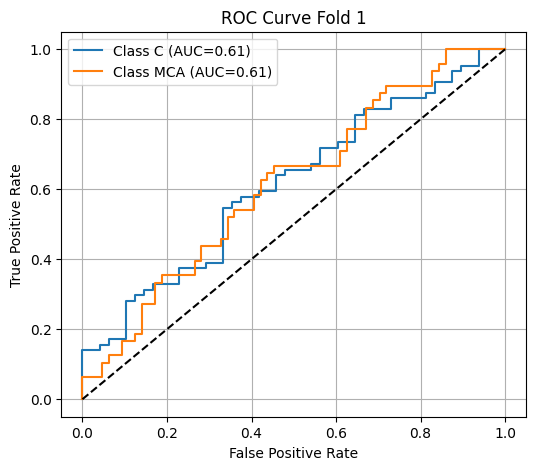

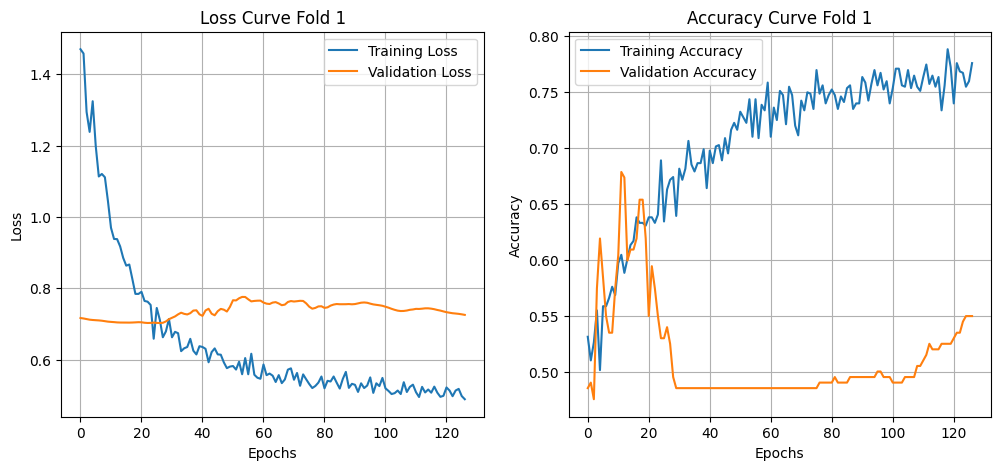

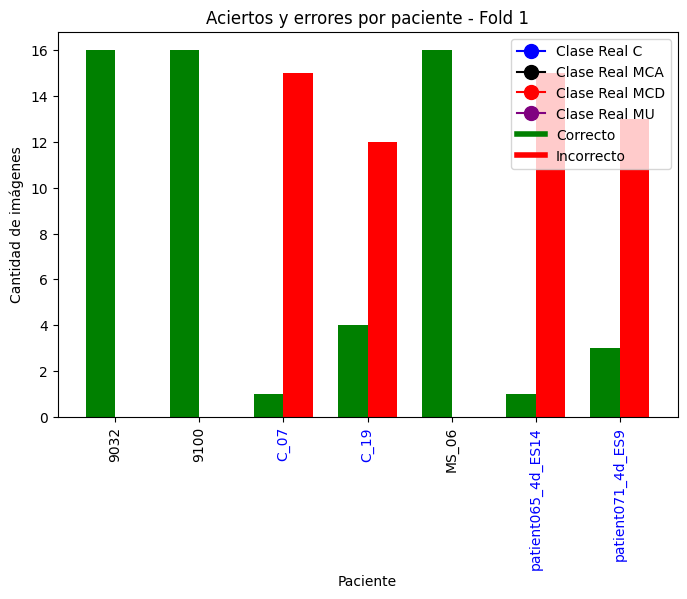

Graficando resultados del fold 2...


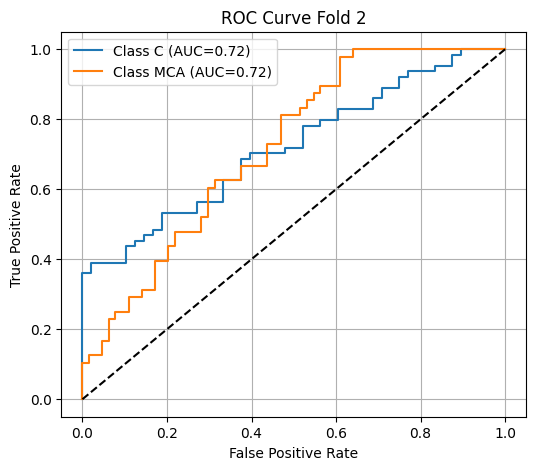

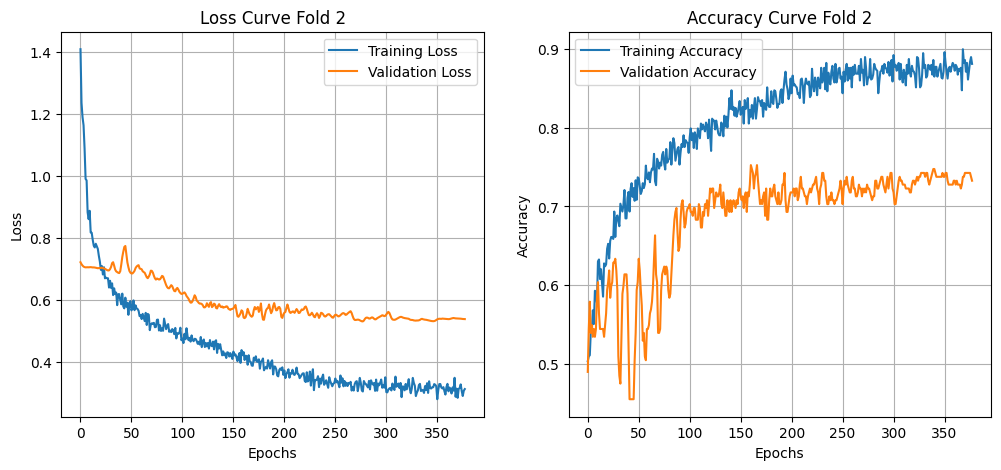

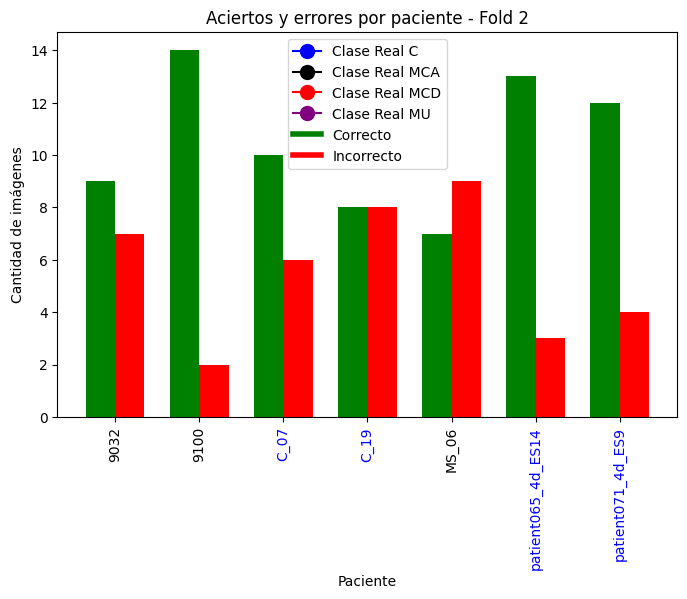

Graficando resultados del fold 3...


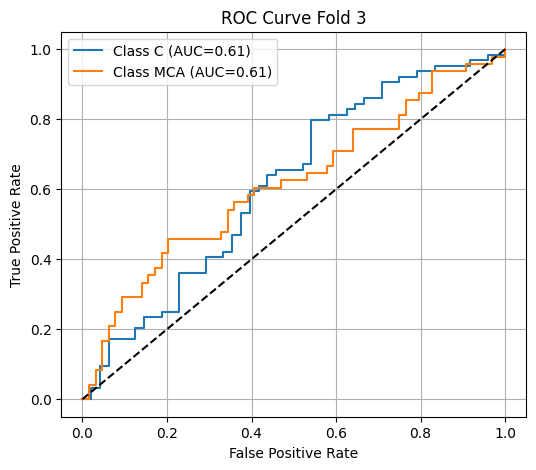

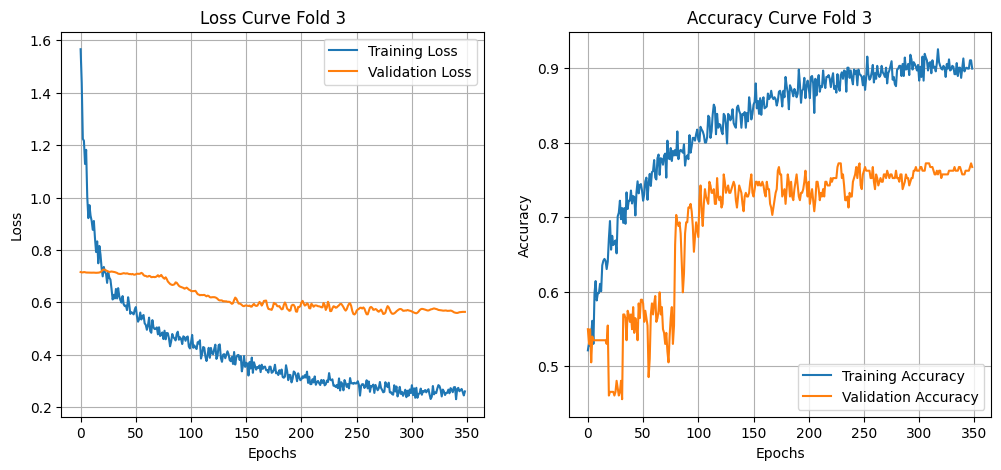

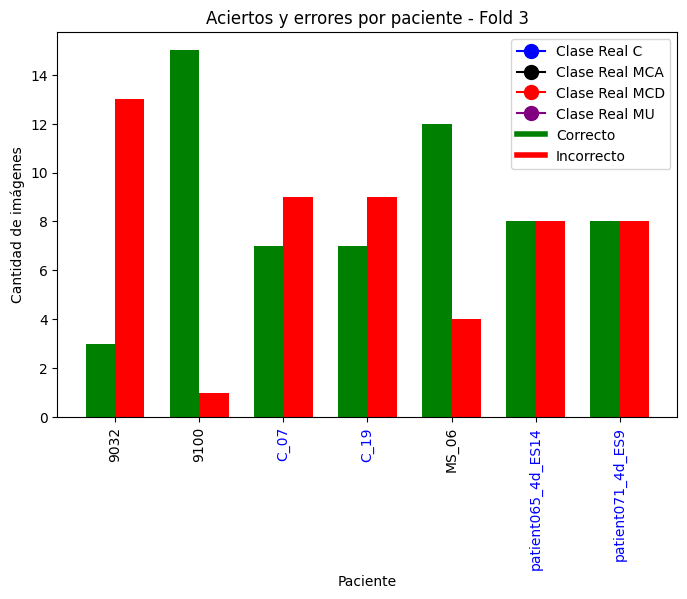

Graficando resultados del fold 4...


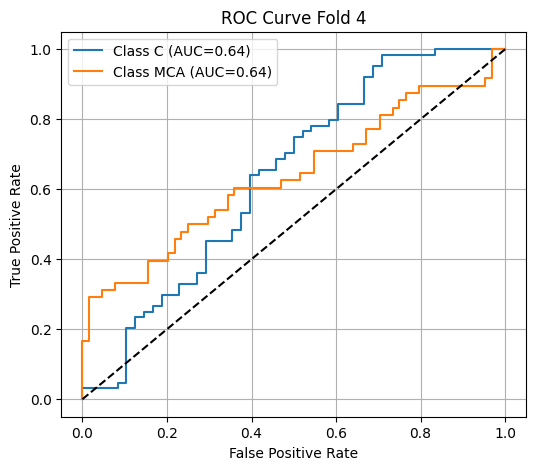

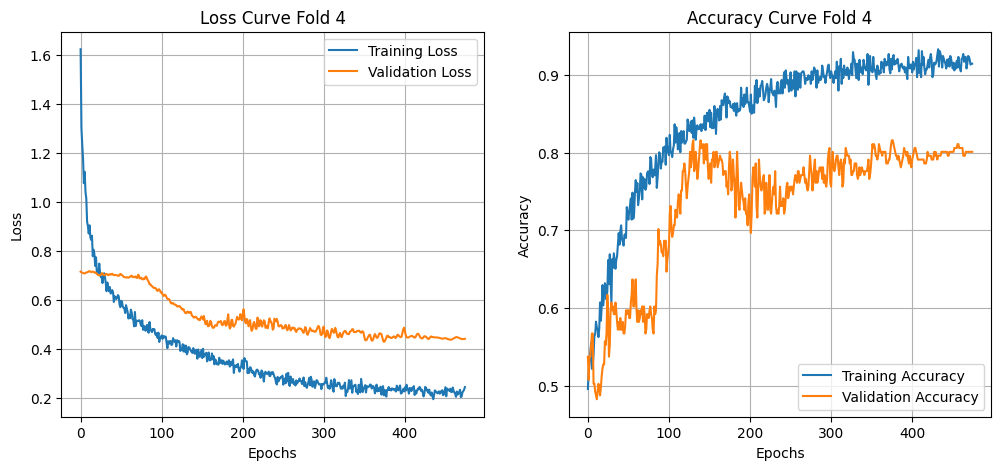

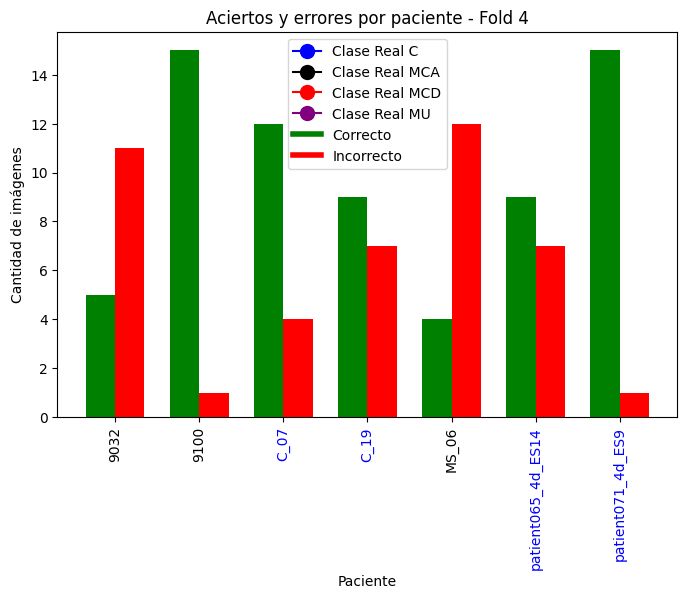

Graficando resultados del fold 5...


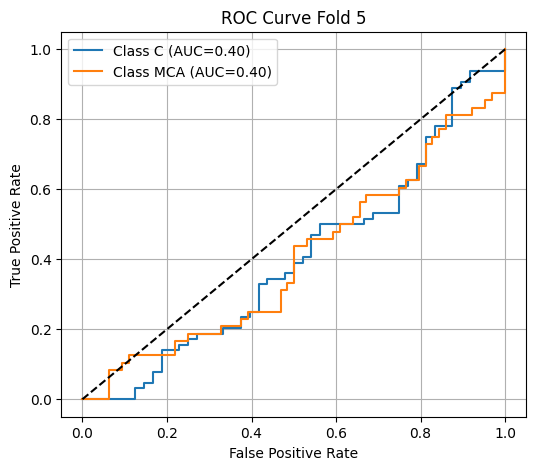

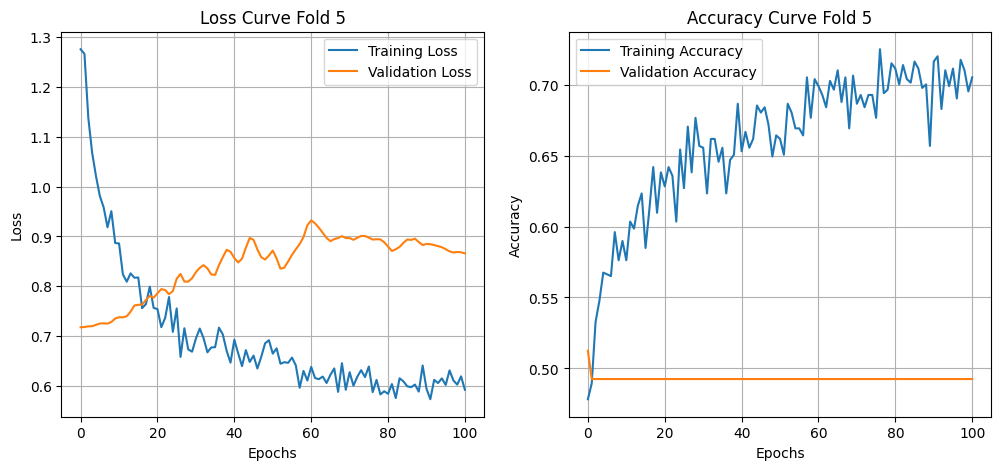

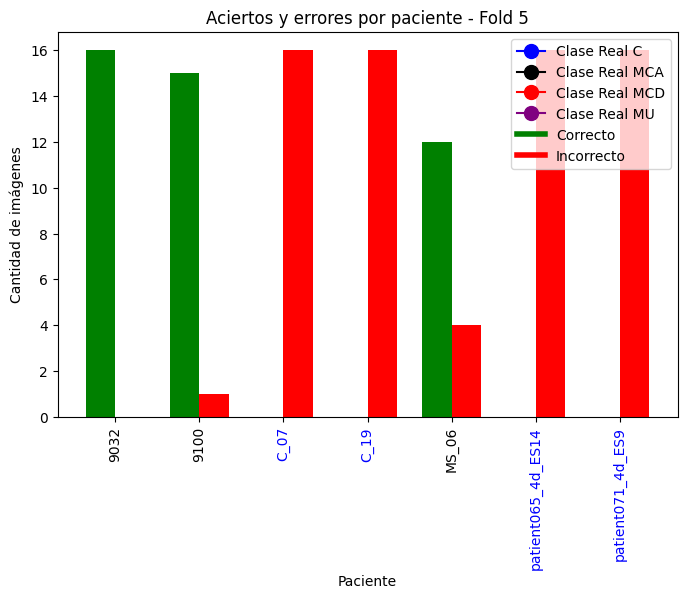

In [141]:
for fold_idx, result in enumerate(fold_results):
    print(f"Graficando resultados del fold {fold_idx+1}...")

    preds = result["predictions"]
    history = result["history"]
    auc_scores = result["auc_scores"]
    fpr = result["fpr"]
    tpr = result["tpr"]

    ## 1. Curva ROC
    plt.figure(figsize=(6, 5))
    for i in range(test_labels2_circ.shape[1]):
        plt.plot(fpr[i], tpr[i], label=f'Class {Encoder2.categories_[0][i]} (AUC={auc_scores[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve Fold {fold_idx+1}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    ## 2. Loss & Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Loss Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()
    plt.show()

    ## 3. Correctos/Incorrectos por paciente
    df = df_test2_circ.copy()
    df["pred"] = [Encoder2.categories_[0][i] for i in preds.argmax(axis=1)]
    df["correct"] = df["pred"] == df["class"]
    df_grouped = df.groupby("patient_name")["correct"].value_counts().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    bar_width = 0.35
    x = np.arange(len(df_grouped))

    ax.bar(x - bar_width/2, df_grouped[True], width=bar_width, label="Correcto", color="green")
    ax.bar(x + bar_width/2, df_grouped[False], width=bar_width, label="Incorrecto", color="red")

    color_map = {
        "C": "blue",
        "MCA": "black",
        "MCD": "red",
        "MU": "purple"
    }

    # Obtener color por paciente
    colores = [
        color_map.get(df[df["patient_name"] == p]["class"].iloc[0], "gray")
        for p in df_grouped.index
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(df_grouped.index)
    for tick, color in zip(ax.get_xticklabels(), colores):
        tick.set_color(color)
    plt.xticks(rotation=90)

    ax.set_xlabel("Paciente")
    ax.set_ylabel("Cantidad de imágenes")
    ax.set_title(f"Aciertos y errores por paciente - Fold {fold_idx+1}")
    handles_clases = [
        mlines.Line2D([], [], marker='o', color=color, label=f'Clase Real {clase}', markersize=10)
        for clase, color in color_map.items()
    ]

    handle_correcto = mlines.Line2D([], [], color='green', lw=4, label='Correcto')
    handle_incorrecto = mlines.Line2D([], [], color='red', lw=4, label='Incorrecto')

    ax.legend(handles=handles_clases + [handle_correcto, handle_incorrecto])

    plt.show()


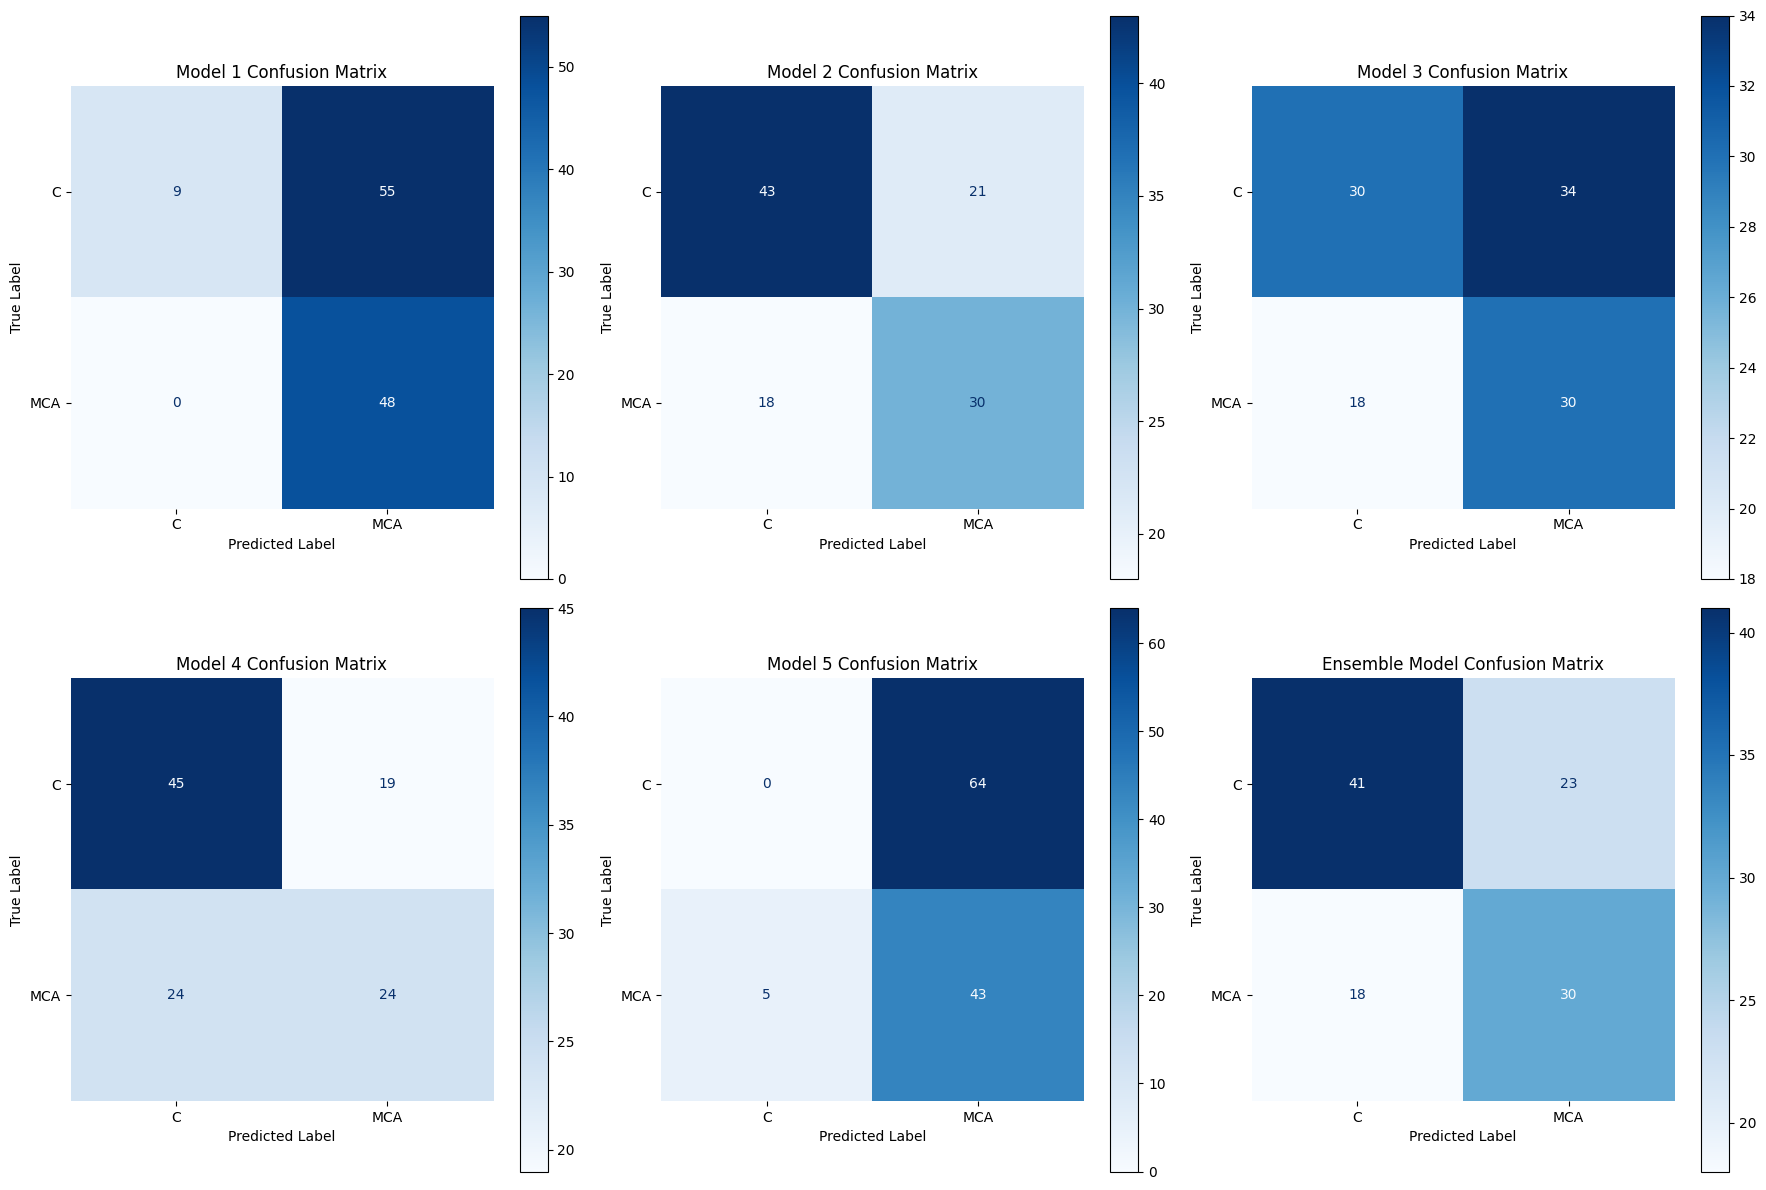

In [142]:
plot_confusion_matrices(models, q_test_images2_circ, test_labels2_circ, class_names)

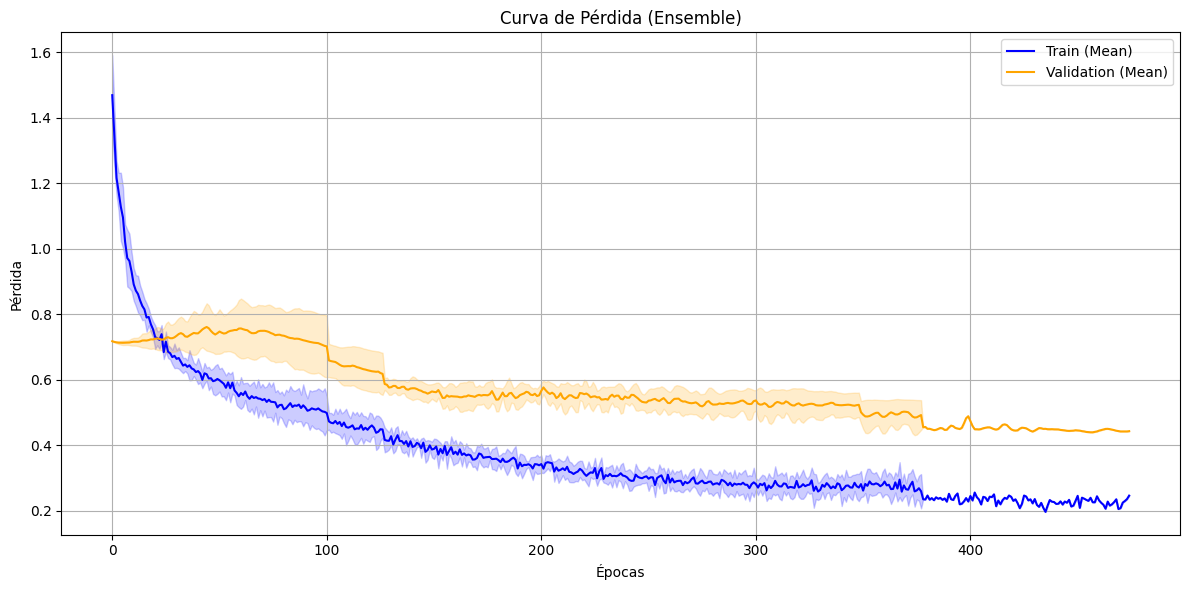

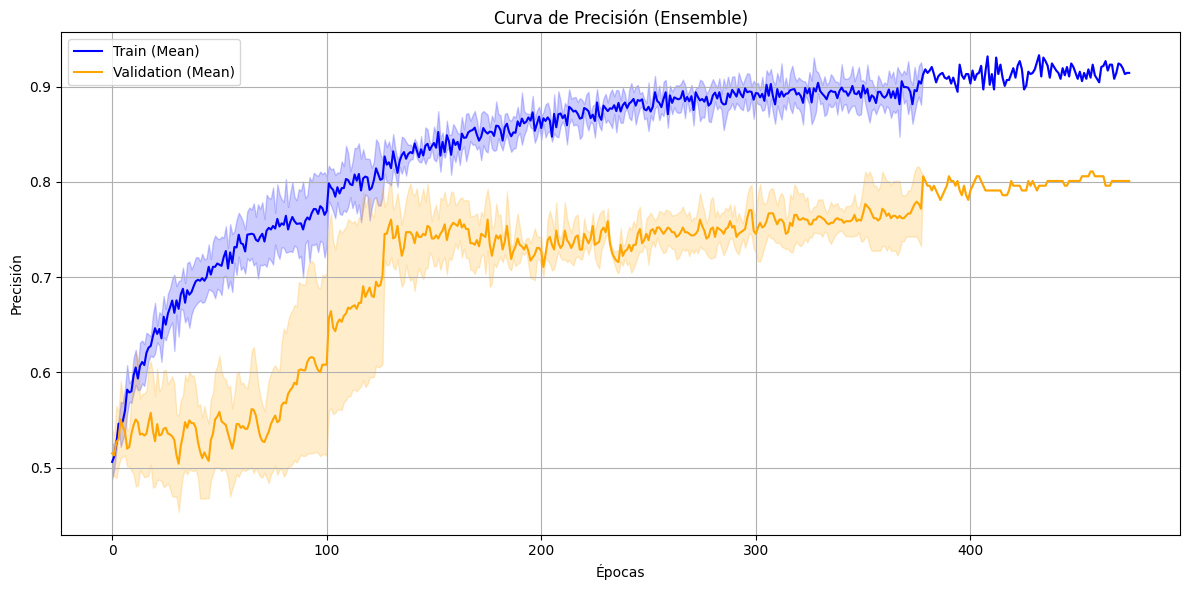

In [ ]:
plot_ensemble_curve(histories)

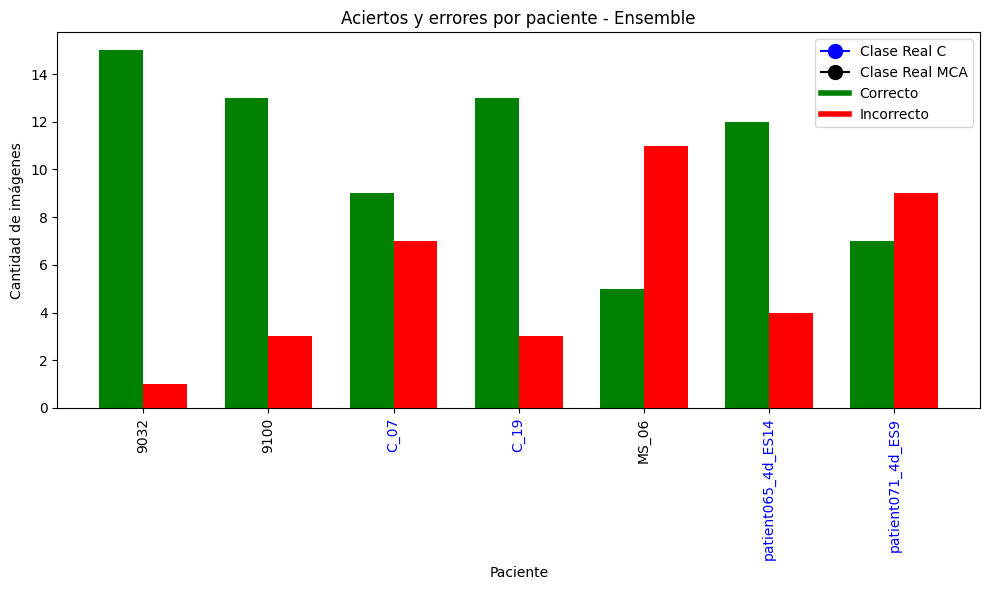

In [43]:
plot_ensemble_patients(models, histories, q_test_images2_rad, df_test2_rad, Encoder2)

## CNN

### KFold

In [131]:
kf.get_n_splits(imgs_tf2_circ,labels2_circ)
histories = []
for fold, (train_idx, val_idx) in enumerate(kf.split(imgs_tf2_circ,labels2_circ)):
    print(f"Entrenando fold {fold+1}/{k}...")
    
    # Dividir los datos en train y validation para este fold
    train_images, val_images = imgs_tf2_circ[train_idx], imgs_tf2_circ[val_idx]
    train_labels, val_labels = labels2_circ[train_idx], labels2_circ[val_idx]
    
    # Instanciar el modelo
    model = cnn(
        input_size=[64, 64], 
        learning_rate=0.001, 
        activation='relu', 
        dropout=0.3, 
        regularization=0.001,
        num_classes=2, 
        num_layers=3, 
        num_filters=[4, 8, 16], 
        filter_size=3, 
        pool_size=2
    )
    
    checkpoint = ModelCheckpoint(f"checkpoints/cnn_fold{fold+1}_circ.h5", monitor="val_loss", save_best_only=True, verbose=1)
    
    # Entrenar el modelo
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        batch_size=512,
        epochs=500,
        verbose=2,
        callbacks=[checkpoint, lr_callback, early_stopping]
    )
    
    # Guardar el historial de entrenamiento
    with open(f"history/cnn_fold{fold+1}_circ.pkl", "wb") as f:
        pickle.dump(history.history, f)
    
    histories.append(history.history)

Entrenando fold 1/5...
Epoch 1/500

Epoch 1: val_loss improved from inf to 0.71423, saving model to checkpoints\cnn_fold1_circ.h5
2/2 - 1s - loss: 1.4695 - accuracy: 0.4851 - val_loss: 0.7142 - val_accuracy: 0.4950 - lr: 0.0010 - 744ms/epoch - 372ms/step
Epoch 2/500

Epoch 2: val_loss did not improve from 0.71423
2/2 - 0s - loss: 1.2136 - accuracy: 0.5037 - val_loss: 0.7161 - val_accuracy: 0.4851 - lr: 0.0010 - 106ms/epoch - 53ms/step
Epoch 3/500

Epoch 3: val_loss did not improve from 0.71423
2/2 - 0s - loss: 1.1435 - accuracy: 0.5670 - val_loss: 0.7176 - val_accuracy: 0.4851 - lr: 0.0010 - 102ms/epoch - 51ms/step
Epoch 4/500

Epoch 4: val_loss did not improve from 0.71423
2/2 - 0s - loss: 1.1440 - accuracy: 0.5496 - val_loss: 0.7184 - val_accuracy: 0.4851 - lr: 0.0010 - 101ms/epoch - 50ms/step
Epoch 5/500

Epoch 5: val_loss did not improve from 0.71423
2/2 - 0s - loss: 1.0767 - accuracy: 0.5149 - val_loss: 0.7179 - val_accuracy: 0.4851 - lr: 0.0010 - 102ms/epoch - 51ms/step
Epoch 6/5

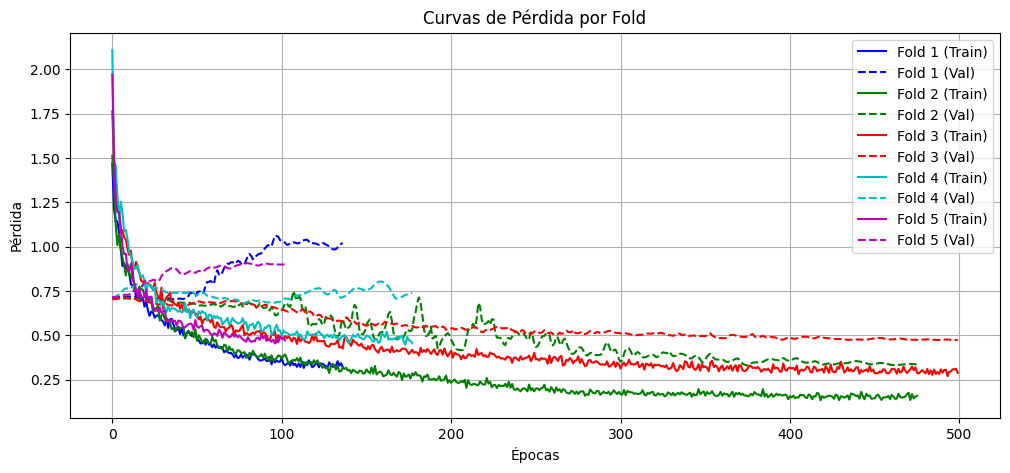

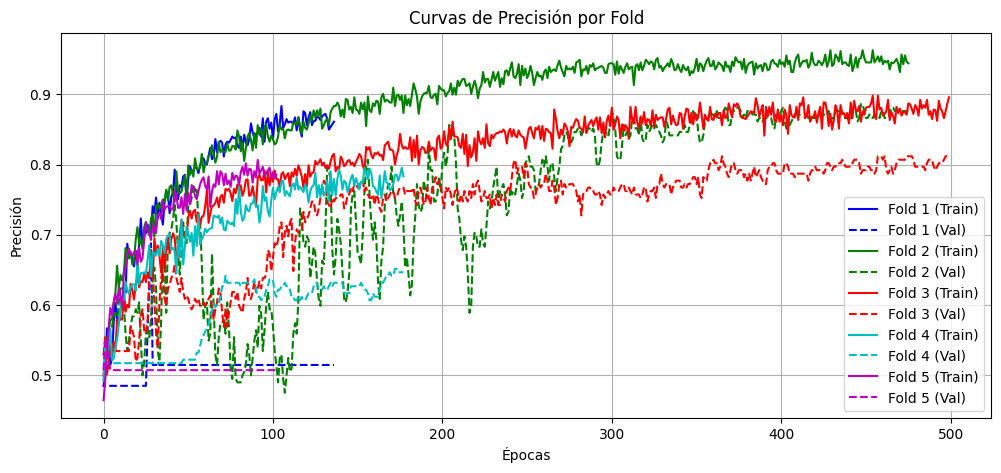

In [132]:
colors = ['b', 'g', 'r', 'c', 'm']
linestyles = ['-', '--', '-.', ':', '-']

# Gráfica de pérdida
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['loss'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_loss'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida por Fold')
plt.legend()
plt.grid()
plt.show()

# Gráfica de precisión
plt.figure(figsize=(12, 5))
for i, history in enumerate(histories):
    plt.plot(history['accuracy'], label=f'Fold {i+1} (Train)', color=colors[i], linestyle=linestyles[0])
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} (Val)', color=colors[i], linestyle=linestyles[1])

plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Curvas de Precisión por Fold')
plt.legend()
plt.grid()
plt.show()

In [44]:
model_paths = [f"checkpoints/cnn_fold{i+1}_circ.h5" for i in range(5)]
history_paths = [f"history/cnn_fold{i+1}_circ.pkl" for i in range(5)]

models = [load_model(path) for path in model_paths]
histories = [pickle.load(open(path, "rb")) for path in history_paths]

In [134]:
fold_results = []

for fold_idx, (model, history) in enumerate(zip(models, histories)):
    print(f"Evaluando fold {fold_idx+1}...")
    
    # Predicciones
    preds = model.predict(test_imgs_tf2_circ)
    
    # AUC por clase
    auc_scores = []
    fpr = dict()
    tpr = dict()
    thresholds = dict()

    for i in range(test_labels2_circ.shape[1]):
        auc = roc_auc_score(test_labels2_circ[:, i], preds[:, i])
        auc_scores.append(auc)
        fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels2_circ[:, i], preds[:, i])

    mean_auc = np.mean(auc_scores)
    
    # F1 y ACC
    f1 = f1_score(test_labels2_circ, np.round(preds), average='micro')
    acc = accuracy_score(test_labels2_circ, np.round(preds))
    
    # Guardar resultados
    fold_results.append({
        "predictions": preds,
        "history": history,
        "auc_scores": auc_scores,
        "fpr": fpr,
        "tpr": tpr,
        "mean_auc": mean_auc,
        "f1": f1,
        "acc": acc
    })

Evaluando fold 1...
4/4 [==============================] - 0s 2ms/step
Evaluando fold 2...
4/4 [==============================] - 0s 2ms/step
Evaluando fold 3...
4/4 [==============================] - 0s 2ms/step
Evaluando fold 4...
4/4 [==============================] - 0s 2ms/step
Evaluando fold 5...
4/4 [==============================] - 0s 2ms/step


Graficando resultados del fold 1...


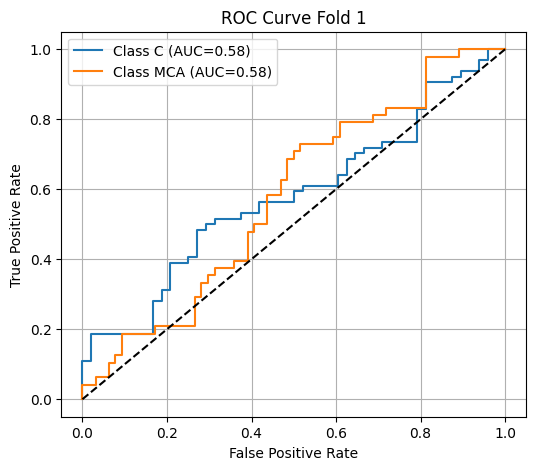

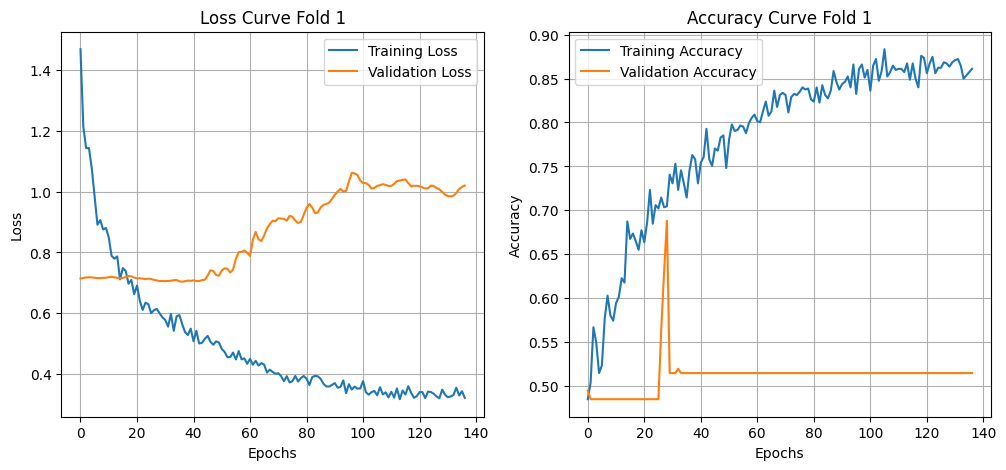

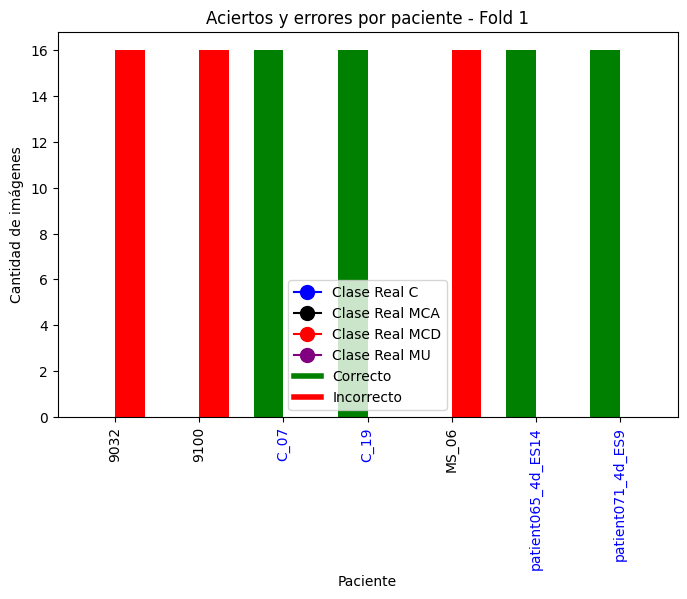

Graficando resultados del fold 2...


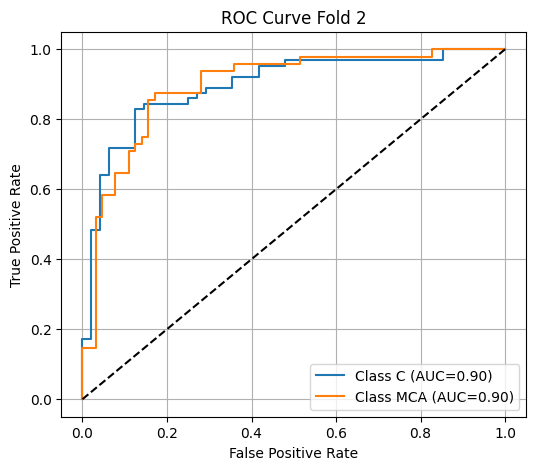

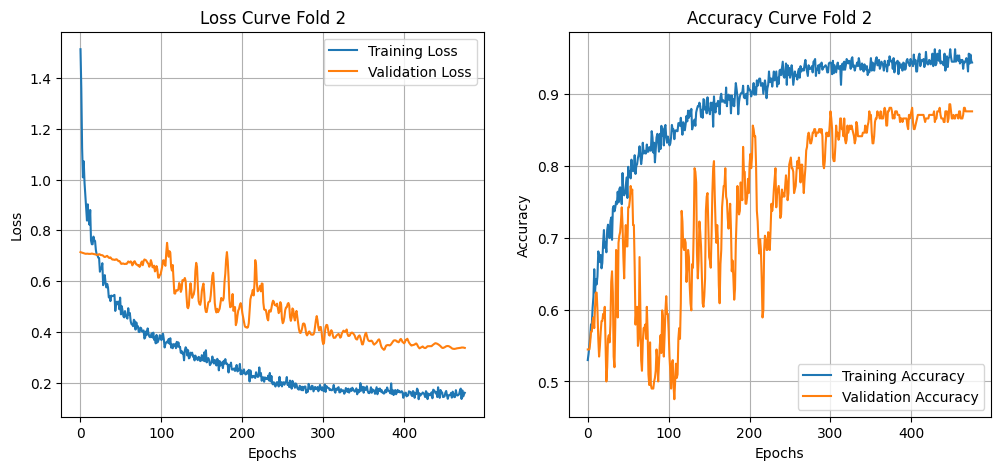

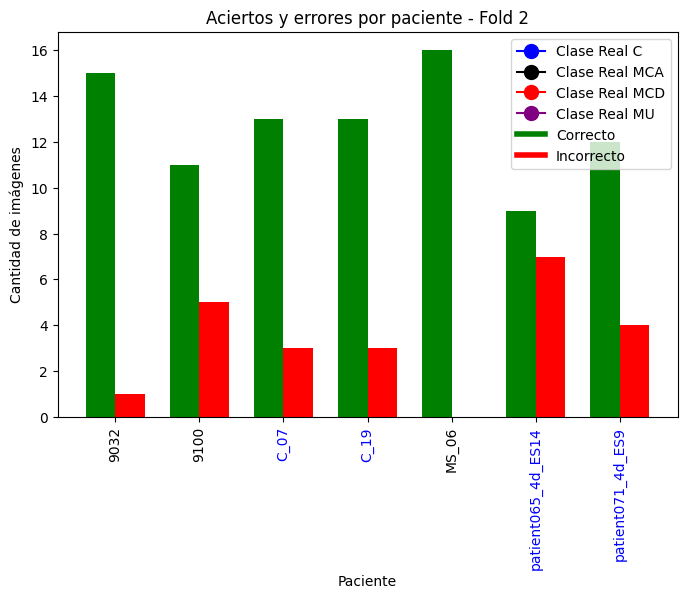

Graficando resultados del fold 3...


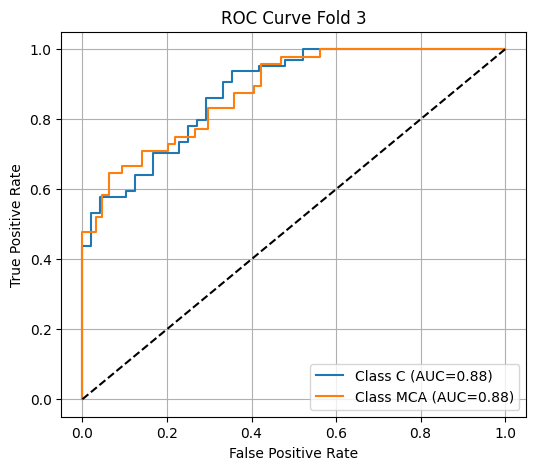

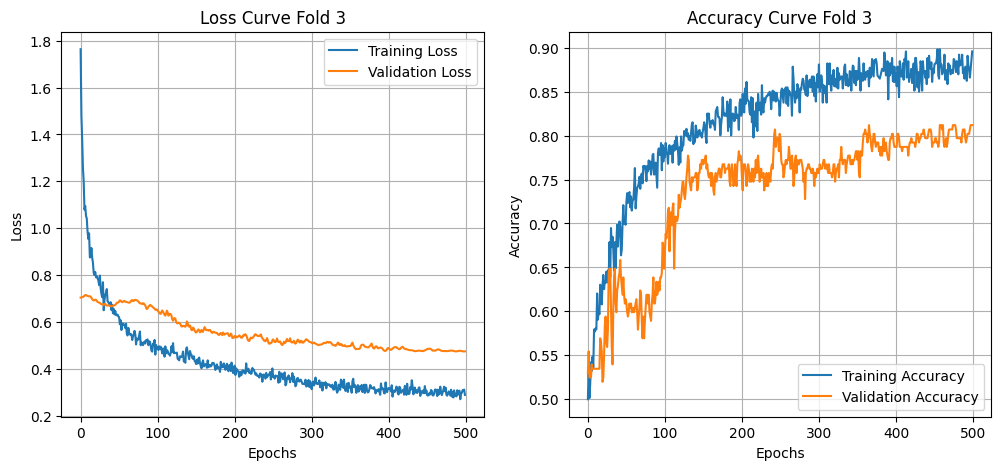

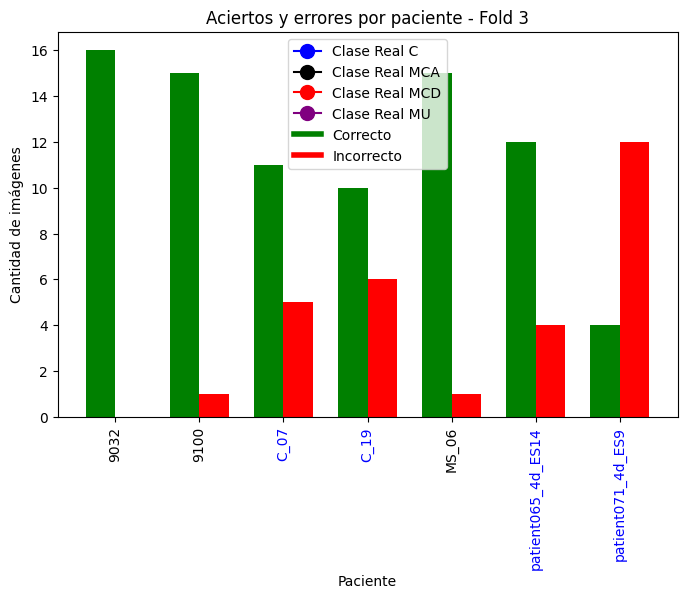

Graficando resultados del fold 4...


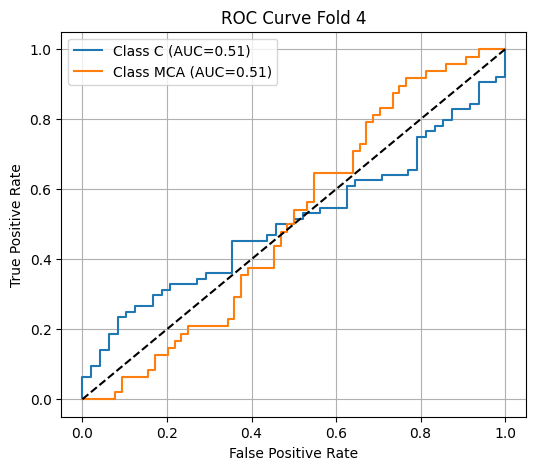

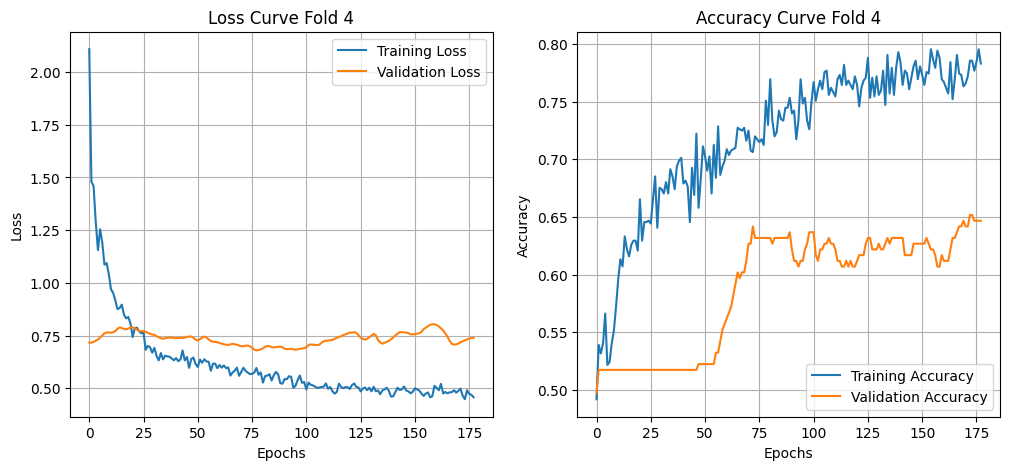

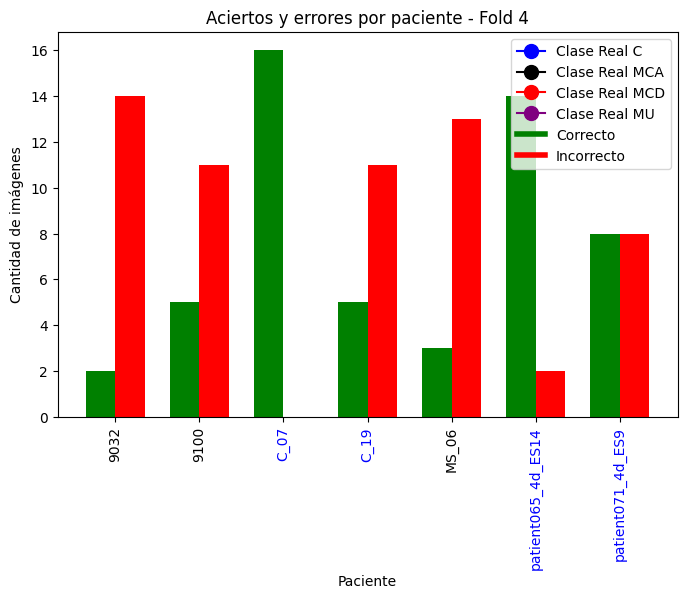

Graficando resultados del fold 5...


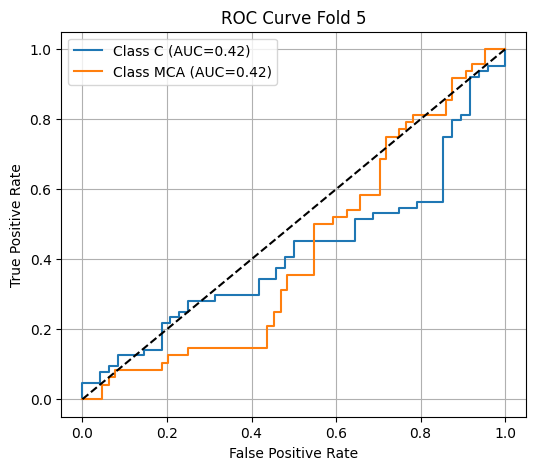

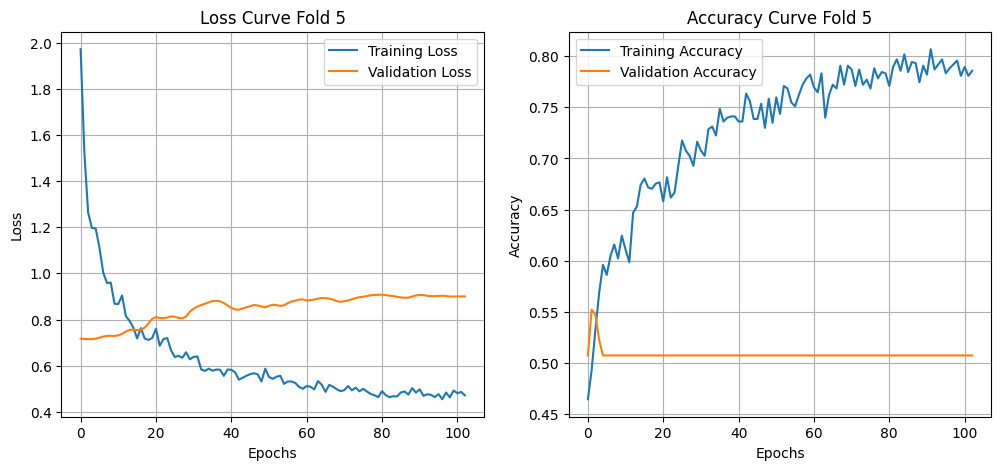

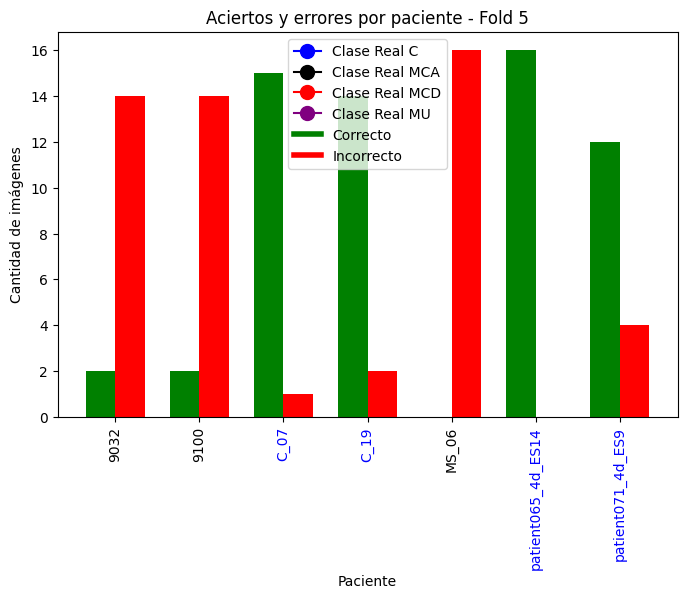

In [135]:
for fold_idx, result in enumerate(fold_results):
    print(f"Graficando resultados del fold {fold_idx+1}...")

    preds = result["predictions"]
    history = result["history"]
    auc_scores = result["auc_scores"]
    fpr = result["fpr"]
    tpr = result["tpr"]

    ## 1. Curva ROC
    plt.figure(figsize=(6, 5))
    for i in range(test_labels2_circ.shape[1]):
        plt.plot(fpr[i], tpr[i], label=f'Class {Encoder2.categories_[0][i]} (AUC={auc_scores[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve Fold {fold_idx+1}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    ## 2. Loss & Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Loss Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Curve Fold {fold_idx+1}')
    plt.legend()
    plt.grid()
    plt.show()

    ## 3. Correctos/Incorrectos por paciente
    df = df_test2_circ.copy()
    df["pred"] = [Encoder2.categories_[0][i] for i in preds.argmax(axis=1)]
    df["correct"] = df["pred"] == df["class"]
    df_grouped = df.groupby("patient_name")["correct"].value_counts().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    bar_width = 0.35
    x = np.arange(len(df_grouped))

    ax.bar(x - bar_width/2, df_grouped[True], width=bar_width, label="Correcto", color="green")
    ax.bar(x + bar_width/2, df_grouped[False], width=bar_width, label="Incorrecto", color="red")

    color_map = {
        "C": "blue",
        "MCA": "black",
        "MCD": "red",
        "MU": "purple"
    }

    # Obtener color por paciente
    colores = [
        color_map.get(df[df["patient_name"] == p]["class"].iloc[0], "gray")
        for p in df_grouped.index
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(df_grouped.index)
    for tick, color in zip(ax.get_xticklabels(), colores):
        tick.set_color(color)
    plt.xticks(rotation=90)

    ax.set_xlabel("Paciente")
    ax.set_ylabel("Cantidad de imágenes")
    ax.set_title(f"Aciertos y errores por paciente - Fold {fold_idx+1}")
    handles_clases = [
        mlines.Line2D([], [], marker='o', color=color, label=f'Clase Real {clase}', markersize=10)
        for clase, color in color_map.items()
    ]

    handle_correcto = mlines.Line2D([], [], color='green', lw=4, label='Correcto')
    handle_incorrecto = mlines.Line2D([], [], color='red', lw=4, label='Incorrecto')

    ax.legend(handles=handles_clases + [handle_correcto, handle_incorrecto])

    plt.show()


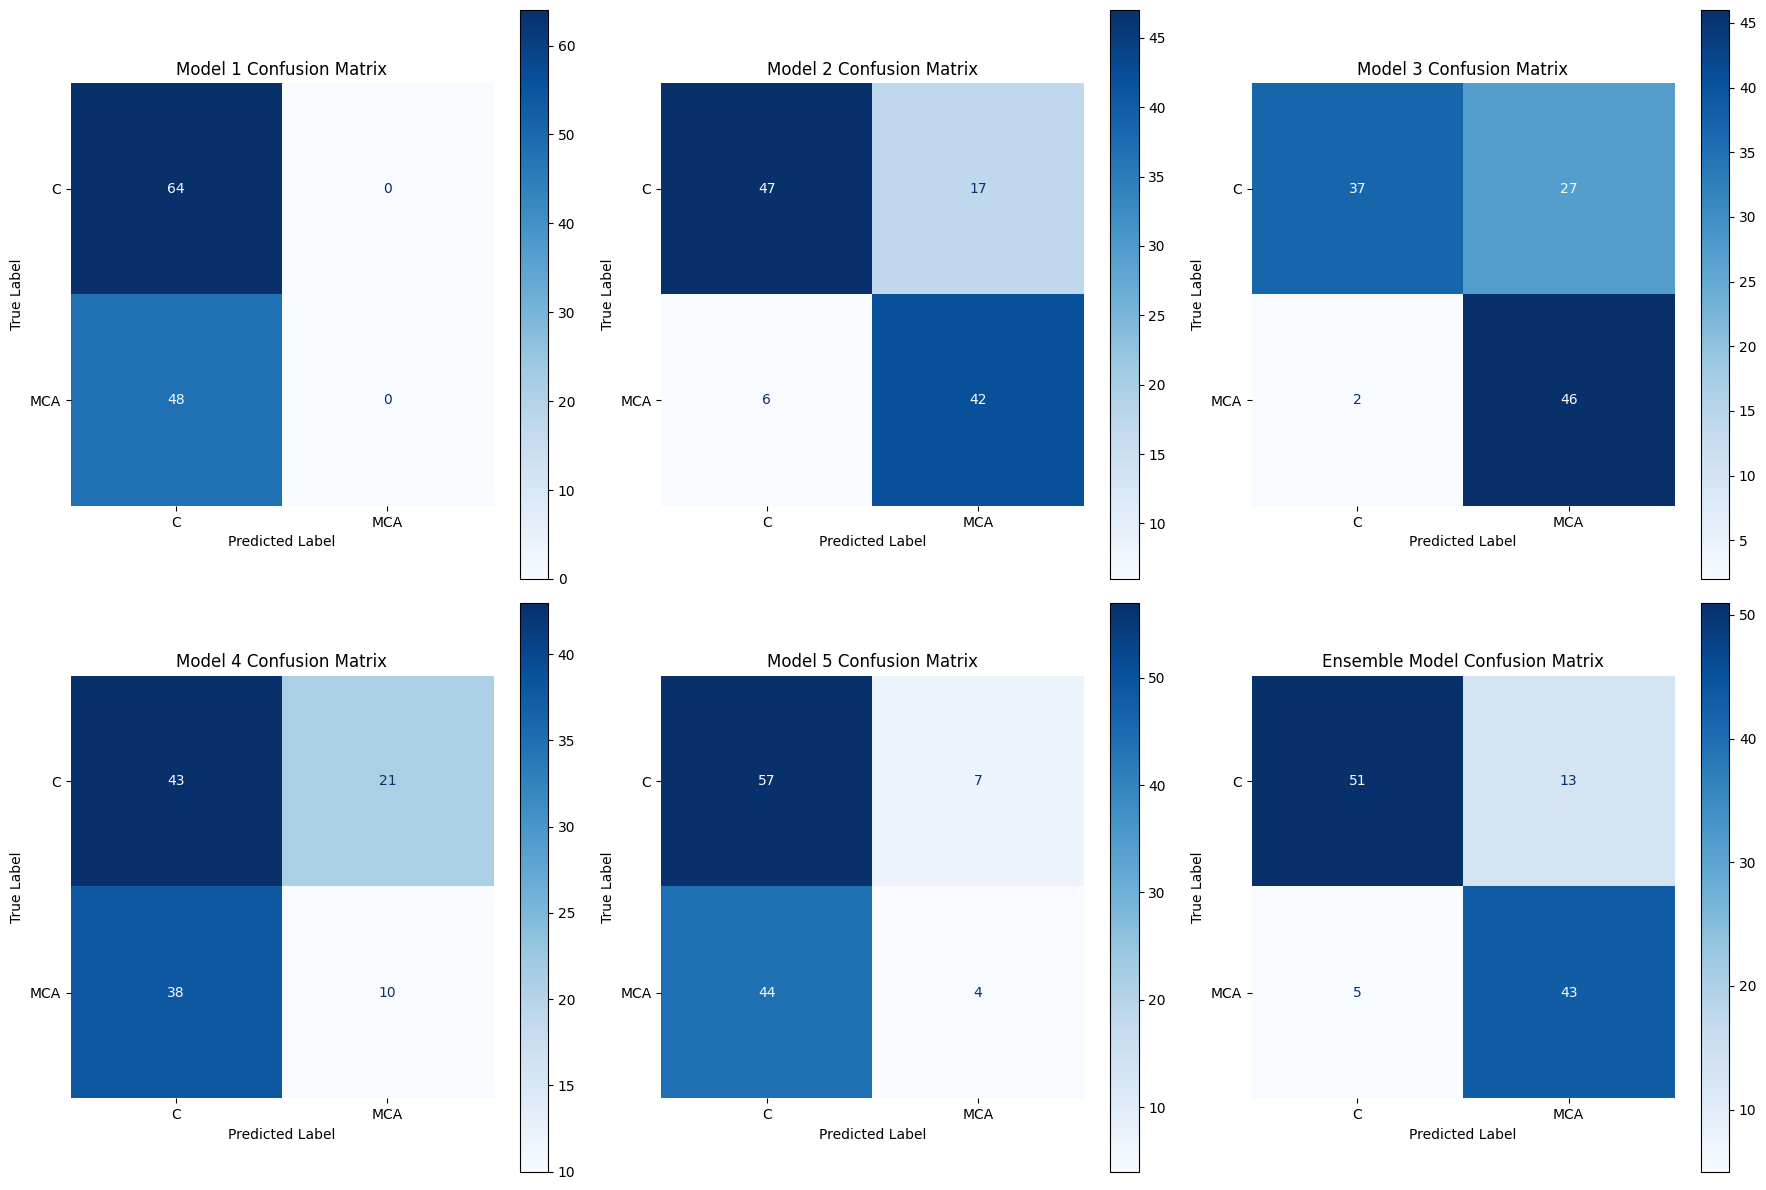

In [136]:
plot_confusion_matrices(models, test_imgs_tf2_circ, test_labels2_circ, class_names)

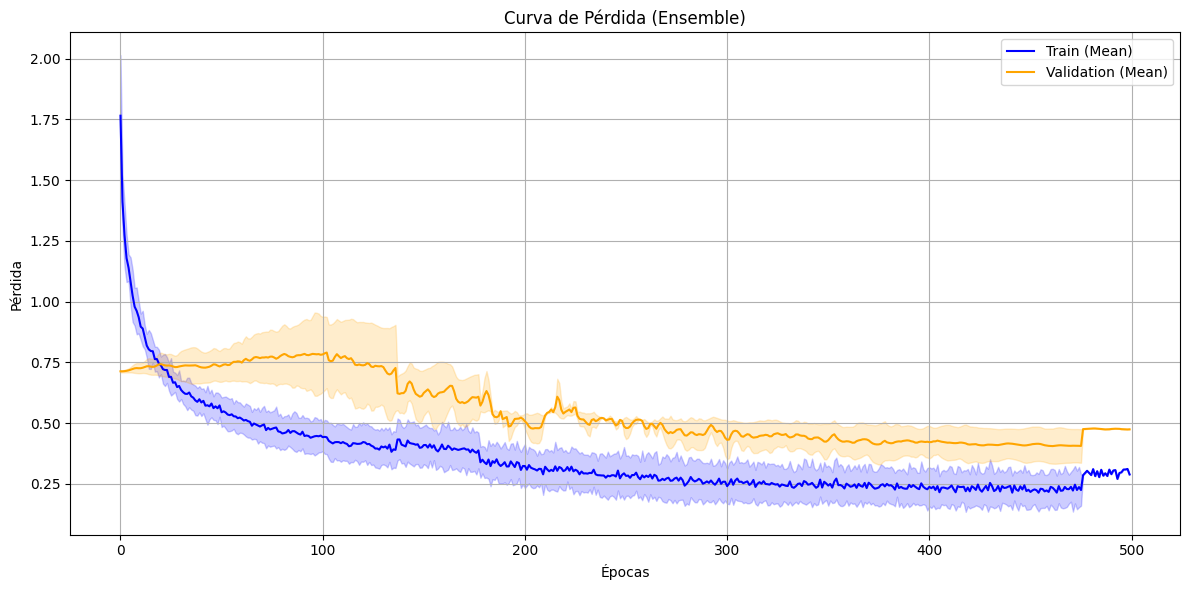

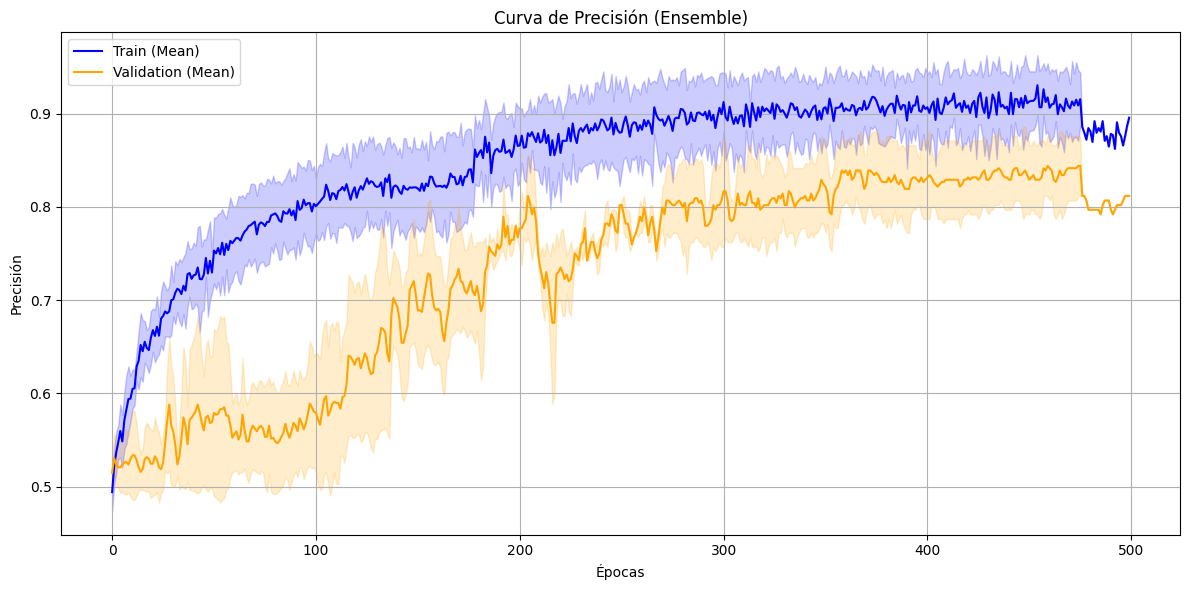

In [ ]:
plot_ensemble_curve(histories)

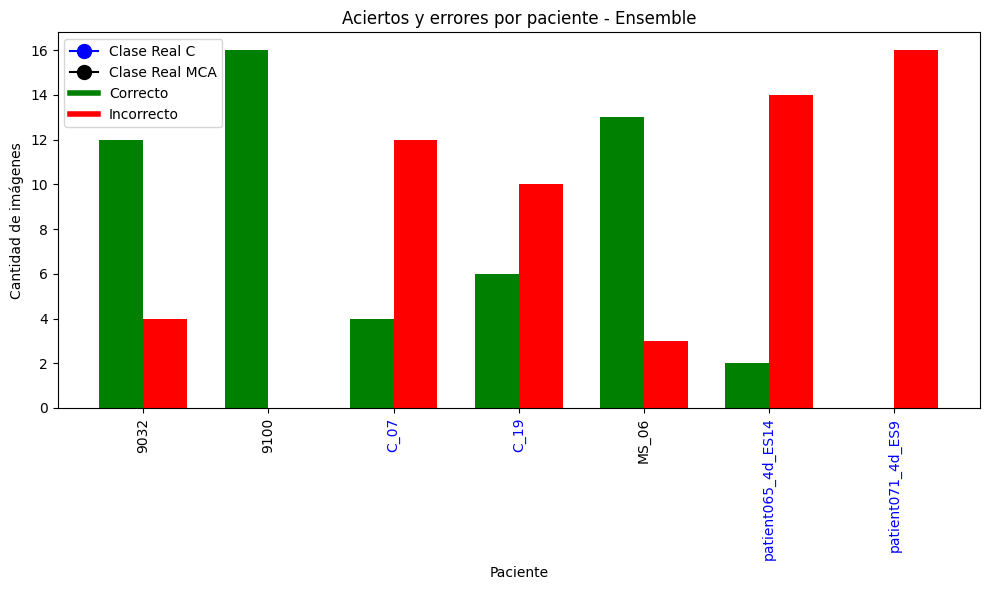

In [46]:
plot_ensemble_patients(models, histories, test_imgs_tf2_rad, df_test2_rad, Encoder2)